In [1]:
import pandas as pd
import os.path

In [2]:
run_basename = '20261003_ParTauDETR_120epochs_logSignificanceIPs'

obj_cls_trsh = 0.5
obj_cls_trsh_str = f'{obj_cls_trsh:.3f}'.replace('.', 'p')
df_dir = f'~/tmp/{run_basename}-model_best-{obj_cls_trsh_str}thr'

df = pd.read_parquet(os.path.expanduser(os.path.join(df_dir, 'z_test_predictions.parquet')))
df_bkg = pd.read_parquet(os.path.expanduser(os.path.join(df_dir, 'qq_test_predictions.parquet')))

In [ ]:
df.head()

,reco_jet_p4,gen_jet_p4,reco_cand_p4s,reco_cand_pdgs,reco_cand_charges,gen_jet_tau_vis_energy,gen_jet_tau_decaymode,gen_jet_tau_charge,gen_jet_tau_full_p4,gen_jet_tau_vis_daughter_p4s,...,file_id,event_id,pred_tau_daughter_meson_classes,pred_tau_daughter_p4s,pred_tau_daughter_charges,tau_decaymode,tau_p4,tau_charge,gen_jet_tau_decaymode_exp,tau_tagging_score
0,"{'pt': 28.01141246226131, 'eta': 0.62594993037...","{'pt': 28.153107903361537, 'eta': 0.6261941075...","[{'pt': 5.355902671813965, 'eta': 0.5888699293...","[211, 211, 211]","[1.0, -1.0, -1.0]",33.873270,10,-1.0,"{'pt': 38.03519545080289, 'eta': 0.62177128643...","[{'pt': 11.50993178607006, 'eta': 0.6079446722...",...,707419,30,"[0, 0, 0]","[{'x': 2.9913933277130127, 'y': -10.6251516342...","[-1, -1, 1]",10,"{'rho': 27.69818115234375, 'phi': -1.292142748...",-1,10,0.998884
1,"{'pt': 33.711961466283675, 'eta': 0.0561190190...","{'pt': 37.870262860551556, 'eta': 0.0393549506...","[{'pt': 6.542594909667969, 'eta': 0.0129832811...","[211, 211, 130, 130, 130, 22]","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]",37.740174,11,1.0,"{'pt': 44.47542908044899, 'eta': 0.02974934168...","[{'pt': 1.7280236876430668, 'eta': 0.080435231...",...,704131,58,"[0, 0, 0]","[{'x': -4.46085262298584, 'y': -6.861167430877...","[-1, 1, 1]",10,"{'rho': 32.954402923583984, 'phi': -2.14368033...",1,11,0.743812
2,"{'pt': 21.47006164302517, 'eta': 0.80450264946...","{'pt': 20.453849993411996, 'eta': 0.8044986719...","[{'pt': 3.5935041904449463, 'eta': 0.843456387...","[211, 130, 22, 22]","[-1.0, 0.0, 0.0, 0.0]",27.449100,1,-1.0,"{'pt': 33.02779795963855, 'eta': 0.82659275463...","[{'pt': 16.89733243315867, 'eta': 0.7958298258...",...,700153,96,"[0, 1]","[{'x': -3.6012396812438965, 'y': -0.3191936910...","[-1, 0]",1,"{'rho': 20.682449340820312, 'phi': -2.99035143...",-1,1,0.987277
3,"{'pt': 18.61034503407158, 'eta': -0.4895068962...","{'pt': 18.13051461595269, 'eta': -0.4886871005...","[{'pt': 13.610233306884766, 'eta': -0.51128113...","[211, 22, 22]","[-1.0, 0.0, 0.0]",20.353977,1,-1.0,"{'pt': 39.9830573215418, 'eta': -0.52251526831...","[{'pt': 4.507004933011936, 'eta': -0.419670486...",...,701674,90,"[0, 1]","[{'x': 2.643929958343506, 'y': -13.48316860198...","[-1, 0]",1,"{'rho': 18.33852195739746, 'phi': -1.376340985...",-1,1,0.999129
4,"{'pt': 0.33594428598124226, 'eta': -1.44753135...","{'pt': 0.3296147730742327, 'eta': -1.453719752...","[{'pt': 0.335944265127182, 'eta': -1.447531461...",[211],[-1.0],0.756709,0,-1.0,"{'pt': 13.797715577505697, 'eta': -1.775068965...","[{'pt': 0.3296147730742327, 'eta': -1.45371975...",...,707294,3,[0],"[{'x': -0.2177824229001999, 'y': 0.27013680338...",[-1],0,"{'rho': 0.34699147939682007, 'phi': 2.24930214...",-1,0,0.265860


In [ ]:
df_bkg.head()

,reco_jet_p4,gen_jet_p4,file_id,event_id,tau_tagging_score
0,"{'pt': 0.12086696160578947, 'eta': 1.406845661...","{'pt': 0.12909645574416256, 'eta': 1.254950457...",600924,17,0.003865
1,"{'pt': 0.6123632245487454, 'eta': 0.8308023167...","{'pt': 0.6165957156444782, 'eta': 0.8351888464...",600987,72,0.277926
2,"{'pt': 0.7788831978960137, 'eta': -0.355236546...","{'pt': 0.721553179814499, 'eta': -0.3596488630...",600967,85,0.044724
3,"{'pt': 0.14319034059739139, 'eta': -0.65791455...","{'pt': 0.17590058166188055, 'eta': -0.67785765...",600438,75,0.007138
4,"{'pt': 0.10625003743039939, 'eta': 0.796472906...","{'pt': 0.08252742499792223, 'eta': 0.835838526...",600593,22,0.004649


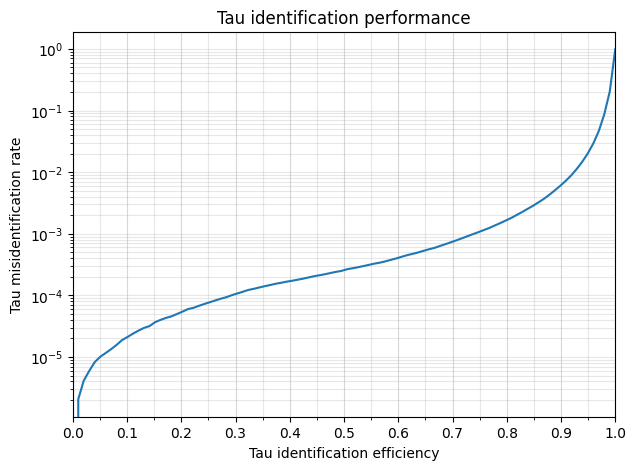

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

signal_scores = df['tau_tagging_score'].to_numpy()
background_scores = df_bkg['tau_tagging_score'].to_numpy()

# Each cut is a percentile of the signal score distribution. For example, the
# 49th percentile cut keeps the highest-scoring 51% of signal jets.
signal_percentiles = np.linspace(0.0, 100.0, 100)
score_cuts = np.percentile(signal_scores, signal_percentiles)
tau_id_efficiency = np.array([
    np.mean(signal_scores >= score_cut) for score_cut in score_cuts
])
tau_misidentification_rate = np.array([
    np.mean(background_scores >= score_cut) for score_cut in score_cuts
])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tau_id_efficiency, tau_misidentification_rate, color='tab:blue')
ax.set(
    xlabel='Tau identification efficiency',
    ylabel='Tau misidentification rate',
    yscale='log',
    xlim=(0, 1),
    title='Tau identification performance',
)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.grid(True, which='both', axis='y', alpha=0.3)
ax.grid(True, which='minor', axis='x', alpha=0.3)
ax.grid(True, which='major', axis='x', alpha=0.5)
plt.show()
plt.close()

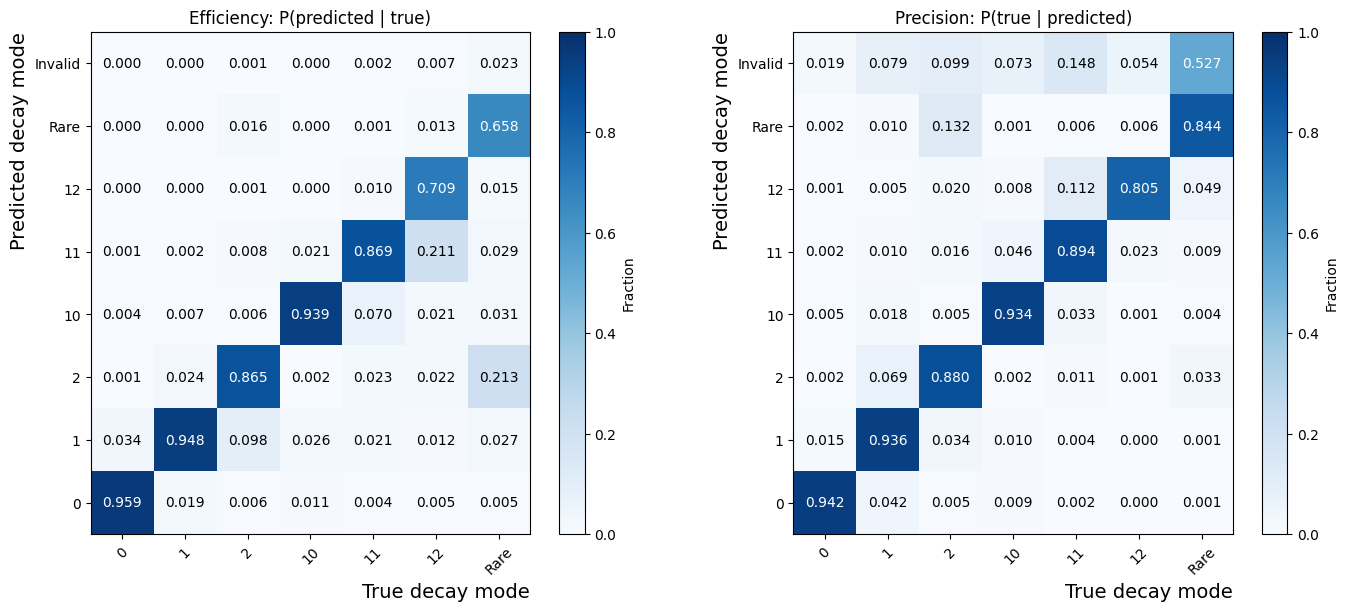

In [6]:
explicit_dms = [0, 1, 2, 10, 11, 12]
labels = explicit_dms + ["Rare"]
predicted_labels = labels + ["Invalid"]


def normalize_truth_dm(dm):
    return dm if dm in explicit_dms else "Rare"


def predict_dm(class_array):
    n_charged = sum(class_value == 0 for class_value in class_array)
    n_neutral = sum(class_value == 1 for class_value in class_array)
    if n_charged % 2 == 0 or n_neutral > 4:
        return "Invalid"
    dm = 5 * (n_charged - 1) + n_neutral
    return dm if dm in explicit_dms else "Rare"


true_dm = df["gen_jet_tau_decaymode"].map(normalize_truth_dm)
predicted_dm = df["pred_tau_daughter_meson_classes"].map(predict_dm)

confusion_efficiency = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="columns",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

confusion_precision = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="index",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Efficiency: P(predicted | true)", "Precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(labels)),
        xticklabels=labels,
        yticks=range(len(predicted_labels)),
        yticklabels=predicted_labels[::-1],
    )
    ax.set_xlabel("True decay mode", loc="right", fontsize=14)
    ax.set_ylabel("Predicted decay mode", loc="top", fontsize=14)
    ax.tick_params(axis="x", rotation=45)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")

plt.show()
plt.close()

The following plots confirm that the model is unable to predict the total charge correctly, as in close to half of the time the model predicts constituents whose charge sum equals zero.

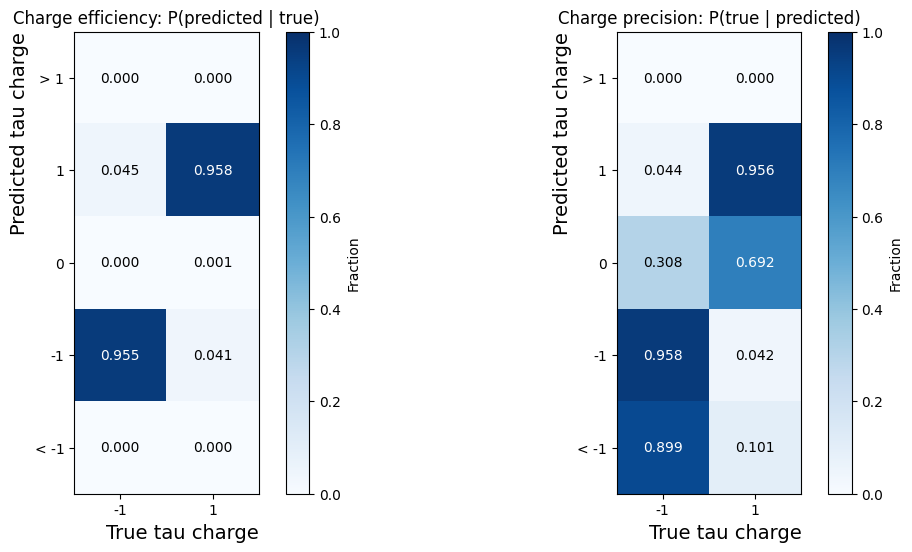

In [7]:
charge_labels = [-1, 1]
predicted_charge_labels = ["< -1", -1, 0, 1, "> 1"]


def predict_charge(charge_array):
    charge = sum(charge_array)
    if charge < -1:
        return "< -1"
    if charge > 1:
        return "> +1"
    return int(charge)


true_charge = df["gen_jet_tau_charge"].astype(int)
predicted_charge = df["pred_tau_daughter_charges"].map(predict_charge)
confusion_efficiency = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="columns",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="index",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Charge efficiency: P(predicted | true)", "Charge precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(predicted_charge_labels)),
        yticklabels=predicted_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("Predicted tau charge", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

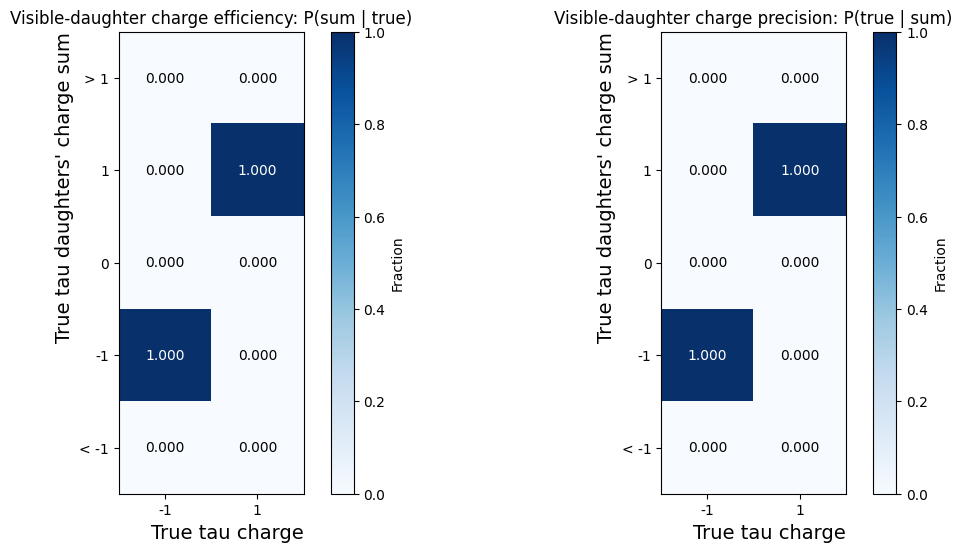

In [8]:
daughter_charge_labels = sorted(
    df["gen_jet_tau_vis_daughter_charges"].map(sum).astype(int).unique()
)


def sum_daughter_charge(charge_array):
    return int(sum(charge_array))


visible_daughter_charge = df["gen_jet_tau_vis_daughter_charges"].map(predict_charge)
confusion_efficiency = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="columns",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="index",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Visible-daughter charge efficiency: P(sum | true)",
        "Visible-daughter charge precision: P(true | sum)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(predicted_charge_labels)),
        yticklabels=predicted_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("True tau daughters' charge sum", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

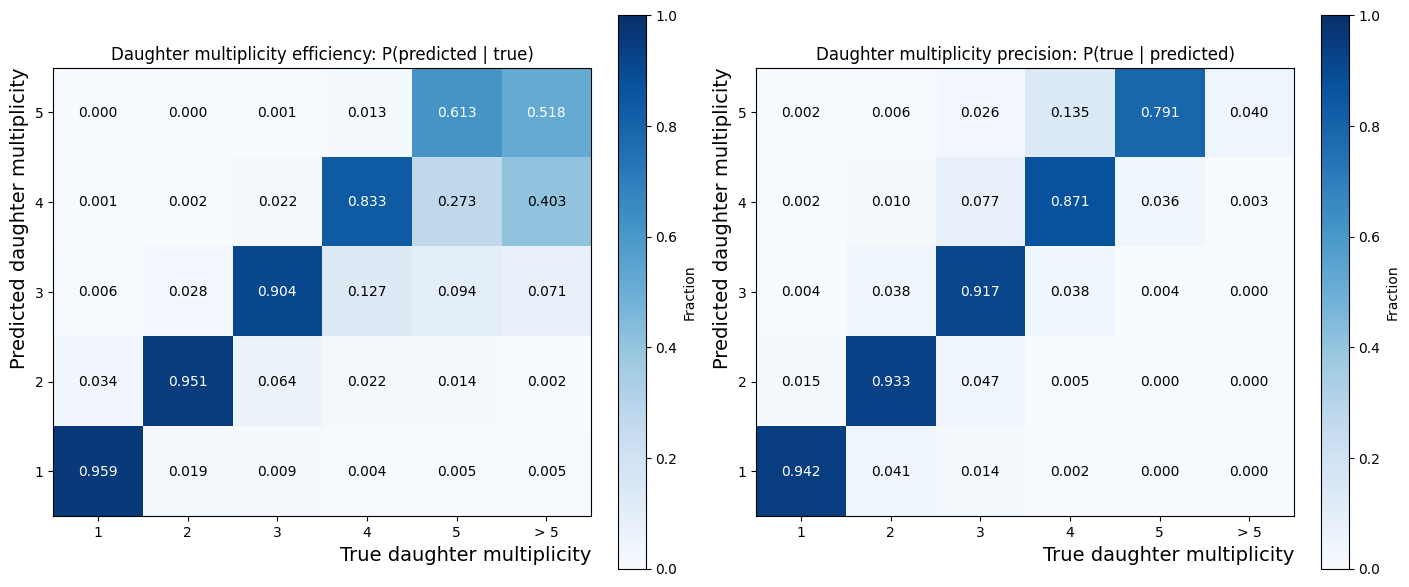

In [9]:
multiplicity_labels = [1, 2, 3, 4, 5, "> 5"]
predicted_multiplicity_labels = sorted(df["pred_tau_daughter_meson_classes"].map(len).unique())


def normalize_true_multiplicity(multiplicity):
    return multiplicity if multiplicity <= 5 else "> 5"


true_multiplicity = df["gen_jet_tau_vis_daughter_pdgs"].map(len).map(
    normalize_true_multiplicity
)
predicted_multiplicity = df["pred_tau_daughter_meson_classes"].map(len)
confusion_efficiency = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="columns",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)
confusion_precision = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="index",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Daughter multiplicity efficiency: P(predicted | true)",
        "Daughter multiplicity precision: P(true | predicted)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(multiplicity_labels)),
        xticklabels=multiplicity_labels,
        yticks=range(len(predicted_multiplicity_labels)),
        yticklabels=predicted_multiplicity_labels[::-1],
    )
    ax.set_xlabel("True daughter multiplicity", loc="right", fontsize=14)
    ax.set_ylabel("Predicted daughter multiplicity", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction", shrink = 0.8)
plt.show()
plt.close()

In [10]:
import awkward as ak
import matplotlib as mpl


n_events = -1
p4_sources = {
    "Generator visible tau": ("gen_jet_tau_p4", False),
    "Generator daughters": ("gen_jet_tau_vis_daughter_p4s", True),
    "Reconstructed jet": ("reco_jet_p4", False),
    "Reconstructed constituents": ("reco_cand_p4s", True),
    "Predicted daughters": ("pred_tau_daughter_p4s", True),
}
nbins = 48
quantity_units = {"pt": "GeV", "eta": "", "phi": "", "mass": "GeV", "energy": "GeV"}
quantity_ranges = {
    "pt": (0, 45, nbins + 1),
    "eta": (-2.7, 2.7, nbins + 1),
    "phi": (-np.pi, np.pi, nbins + 1),
    "mass": (0, 3, nbins + 1),
    "energy": (0, 50, nbins + 1),
}


def has_exactly_one_charged_pion(pdgs):
    return sum(abs(pdg) == 211 for pdg in pdgs) == 1


def is_predicted_single_pion(classes):
    return isinstance(classes, (list, tuple, np.ndarray)) and len(classes) == 1 and classes[0] == 0


one_charged_pion = df["gen_jet_tau_vis_daughter_pdgs"].map(has_exactly_one_charged_pion)
event_selections = {
    "Inclusive": None,
    "Generator one charged pion": one_charged_pion,
    "Generator one charged pion, predicted single pion": (
        one_charged_pion
        & df["pred_tau_daughter_meson_classes"].map(is_predicted_single_pion)
    ),
}


def subset_events(series, event_mask=None):
    if n_events == -1:
        subset = series
    else:
        subset = series.iloc[:n_events]
    if event_mask is None:
        return subset
    return subset[event_mask.loc[subset.index]]


def p4_components(p4_array, predicted=False):
    if predicted:
        return (
            p4_array["x"],
            p4_array["y"],
            p4_array["z"],
            p4_array["t"],
        )

    pt = p4_array["pt"]
    eta = p4_array["eta"]
    phi = p4_array["phi"]
    return (
        pt * np.cos(phi),
        pt * np.sin(phi),
        pt * np.sinh(eta),
        p4_array["energy"],
    )


def summed_p4(p4_array, predicted=False):
    px, py, pz, energy = p4_components(p4_array, predicted=predicted)
    px = ak.sum(px, axis=1)
    py = ak.sum(py, axis=1)
    pz = ak.sum(pz, axis=1)
    energy = ak.sum(energy, axis=1)
    pt = np.hypot(px, py)
    eta = np.arcsinh(ak.where(pt != 0, pz / pt, 0))
    phi = np.arctan2(py, px)
    mass_squared = energy**2 - px**2 - py**2 - pz**2
    mass = np.sqrt(np.maximum(mass_squared, 0))
    return {"pt": pt, "eta": eta, "phi": phi, "mass": mass, "energy": energy}


def histogram_with_uncertainty(values, bins):
    counts, _ = np.histogram(values, bins=bins)
    total = counts.sum()
    fractions = counts / total if total else np.zeros_like(counts, dtype=float)
    uncertainties = np.sqrt(counts) / total if total else np.zeros_like(counts, dtype=float)
    return fractions, uncertainties


def bin_edges(quantity, generator_values, use_quantile_bins):
    lower, upper, number_of_edges = quantity_ranges[quantity]
    if not use_quantile_bins or quantity in [ "eta", "mass" ]:
        return np.linspace(lower, upper, number_of_edges)

    finite_generator_values = generator_values[np.isfinite(generator_values)]
    if finite_generator_values.size == 0:
        raise ValueError("Cannot construct quantile bins without finite generator values.")

    quantiles = np.linspace(0, 1, number_of_edges)
    return np.unique(np.quantile(finite_generator_values, quantiles))


def relative_spread_with_uncertainty(values, relative=True):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan, np.nan

    quantile_probabilities = np.array([0.25, 0.5, 0.75])
    lower_probabilities = quantile_probabilities - 0.05
    upper_probabilities = quantile_probabilities + 0.05
    quantiles = np.quantile(values, quantile_probabilities)
    lower_quartile, median, upper_quartile = quantiles
    if relative and median == 0:
        return np.nan, np.nan
    spread = (upper_quartile - lower_quartile) / median if relative else upper_quartile - lower_quartile
    with np.errstate(divide="ignore", invalid="ignore"):
        local_densities = 0.1 / (
            np.quantile(values, upper_probabilities)
            - np.quantile(values, lower_probabilities)
        )
    if not np.all(np.isfinite(local_densities)) or np.any(local_densities <= 0):
        return spread, np.nan

    covariance = (
        np.minimum.outer(quantile_probabilities, quantile_probabilities)
        - np.outer(quantile_probabilities, quantile_probabilities)
    ) / (len(values) * np.outer(local_densities, local_densities))
    gradient = np.array([-1 / median, -spread / median, 1 / median]) if relative else np.array([-1.0, 0.0, 1.0])
    spread_variance = gradient @ covariance @ gradient
    return spread, np.sqrt(max(spread_variance, 0))


def plot_quantity(quantity, event_mask=None, selection_label="Inclusive", use_quantile_bins=False):
    values = {
        source_name: source_quantity(field, quantity, is_array, event_mask)
        for source_name, (field, is_array) in p4_sources.items()
    }
    generator_values = values["Generator visible tau"]
    bins = bin_edges(quantity, generator_values, use_quantile_bins)
    angular = quantity in ("eta", "phi")

    distributions = {}
    uncertainties = {}
    for source_name, source_values in values.items():
        distributions[source_name], uncertainties[source_name] = histogram_with_uncertainty(
            source_values,
            bins,
        )

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    source_colors = {
        source_name: colors[index % len(colors)]
        for index, source_name in enumerate(p4_sources)
    }
    centers = 0.5 * (bins[1:] + bins[:-1])
    n_panels = 4 if angular else 3
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), constrained_layout=True)
    for source_name in p4_sources:
        color = source_colors[source_name]
        axes[0].stairs(
            distributions[source_name],
            bins,
            label=source_name,
            linewidth=1.5,
            color=color,
        )
        axes[0].errorbar(
            centers,
            distributions[source_name],
            yerr=uncertainties[source_name],
            fmt="none",
            capsize=2,
            alpha=0.5,
            color=color,
        )

    line_style = lambda source_name: '--' if source_name == "Reconstructed constituents" else '-'
    generator_distribution = distributions["Generator visible tau"]
    generator_uncertainty = uncertainties["Generator visible tau"]
    for source_name in list(p4_sources)[1:]:
        color = source_colors[source_name]
        ratio = np.divide(
            distributions[source_name],
            generator_distribution,
            out=np.full_like(generator_distribution, np.nan),
            where=generator_distribution > 0,
        )
        ratio_uncertainty = ratio * np.sqrt(
            np.divide(
                uncertainties[source_name] ** 2,
                distributions[source_name] ** 2,
                out=np.zeros_like(ratio),
                where=distributions[source_name] > 0,
            )
            + np.divide(
                generator_uncertainty**2,
                generator_distribution**2,
                out=np.zeros_like(ratio),
                where=generator_distribution > 0,
            )
        )
        axes[1].plot(
            centers,
            ratio,
            marker="o",
            markersize=3,
            label=source_name,
            color=color,
            linestyle=line_style(source_name),
        )
        axes[1].errorbar(
            centers,
            ratio,
            yerr=ratio_uncertainty,
            fmt="none",
            capsize=2,
            color=color,
        )

    for source_name in ["Reconstructed jet", "Predicted daughters"]:
        color = source_colors[source_name]
        if angular:
            relative_values = values[source_name] - generator_values
            if quantity == "phi":
                relative_values = np.arctan2(np.sin(relative_values), np.cos(relative_values))
        else:
            relative_values = values[source_name] / generator_values
        mask = np.isfinite(relative_values)
        spread = []
        spread_uncertainty = []
        bias = []
        for lower_edge, upper_edge in zip(bins[:-1], bins[1:]):
            bin_values = relative_values[
                mask & (generator_values >= lower_edge) & (generator_values < upper_edge)
            ]
            spread_value, uncertainty = relative_spread_with_uncertainty(bin_values, relative=not angular)
            spread.append(spread_value)
            spread_uncertainty.append(uncertainty)
            bias.append(np.median(bin_values) if len(bin_values) else np.nan)
        axes[2].plot(
            centers,
            spread,
            marker="o",
            markersize=3,
            label=source_name,
            color=color,
            linestyle=line_style(source_name),
        )
        axes[2].errorbar(
            centers,
            spread,
            yerr=spread_uncertainty,
            fmt="none",
            capsize=2,
            color=color,
        )
        if angular:
            axes[3].plot(centers, bias, marker="o", markersize=3, label=source_name, color=color)

    unit = f" [{quantity_units[quantity]}]" if quantity_units[quantity] else ""
    axes[0].set_title(f"{quantity} distribution")
    axes[1].set_title(f"{quantity} ratio to generator")
    axes[2].set_title(f"{quantity} residual width" if angular else f"{quantity} relative spread")
    axes[0].set_ylabel(f"Normalized {quantity}{unit}")
    axes[1].set_ylabel("Ratio to generator")
    residual_unit = " [rad]" if quantity == "phi" else ""
    axes[2].set_ylabel(f"IQR of residual{residual_unit}" if angular else "IQR / median")
    if angular:
        axes[3].set_title(f"{quantity} residual bias")
        axes[3].set_ylabel(f"Median residual{residual_unit}")
        axes[3].axhline(0.0, color="black", linewidth=1, linestyle="--")
        axes[3].legend(fontsize=8)
    for ax in axes:
        ax.set_xlabel(f"Generator visible tau {quantity}{unit}")
        ax.grid(alpha=0.2)
    axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--")
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    axes[2].legend(fontsize=8)
    for axes_idx in range(n_panels):
        axes[axes_idx].set_xlim(bins[0], bins[-1])
    fig.suptitle(selection_label)
    plt.show()
    plt.close()

In [ ]:
def source_quantity(field, quantity, is_array, event_mask=None):
    values = subset_events(df[field], event_mask)
    predicted = field == "pred_tau_daughter_p4s"
    if is_array:
        summed = summed_p4(ak.Array(values.tolist()), predicted=predicted)
        return np.asarray(ak.to_numpy(summed[quantity]))

    result = []
    for record in values:
        pt = float(record["pt"])
        eta = float(record["eta"])
        phi = float(record["phi"])
        if quantity == "mass":
            energy = float(record["energy"])
            value = np.sqrt(max(energy**2 - (pt * np.cosh(eta)) ** 2, 0.0))
        elif quantity == "energy":
            value = float(record["energy"])
        else:
            value = {"pt": pt, "eta": eta, "phi": phi}[quantity]
        result.append(value)
    return np.asarray(result)

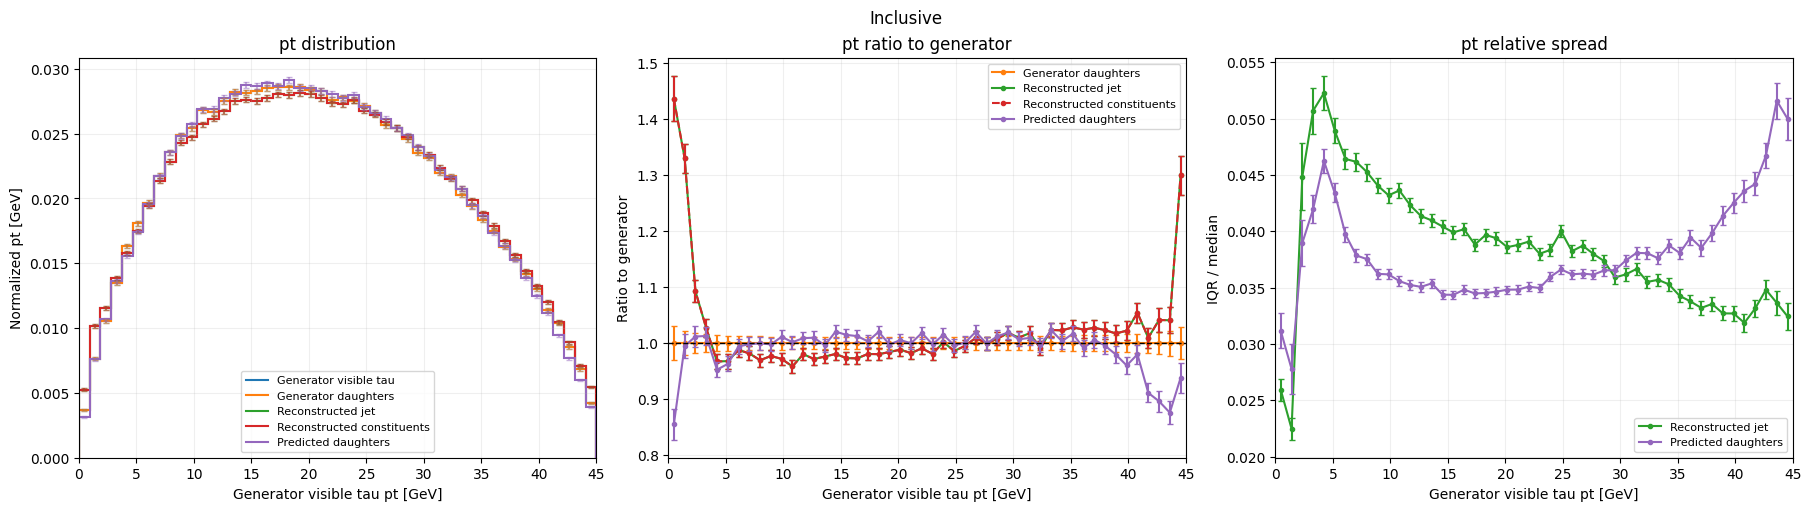

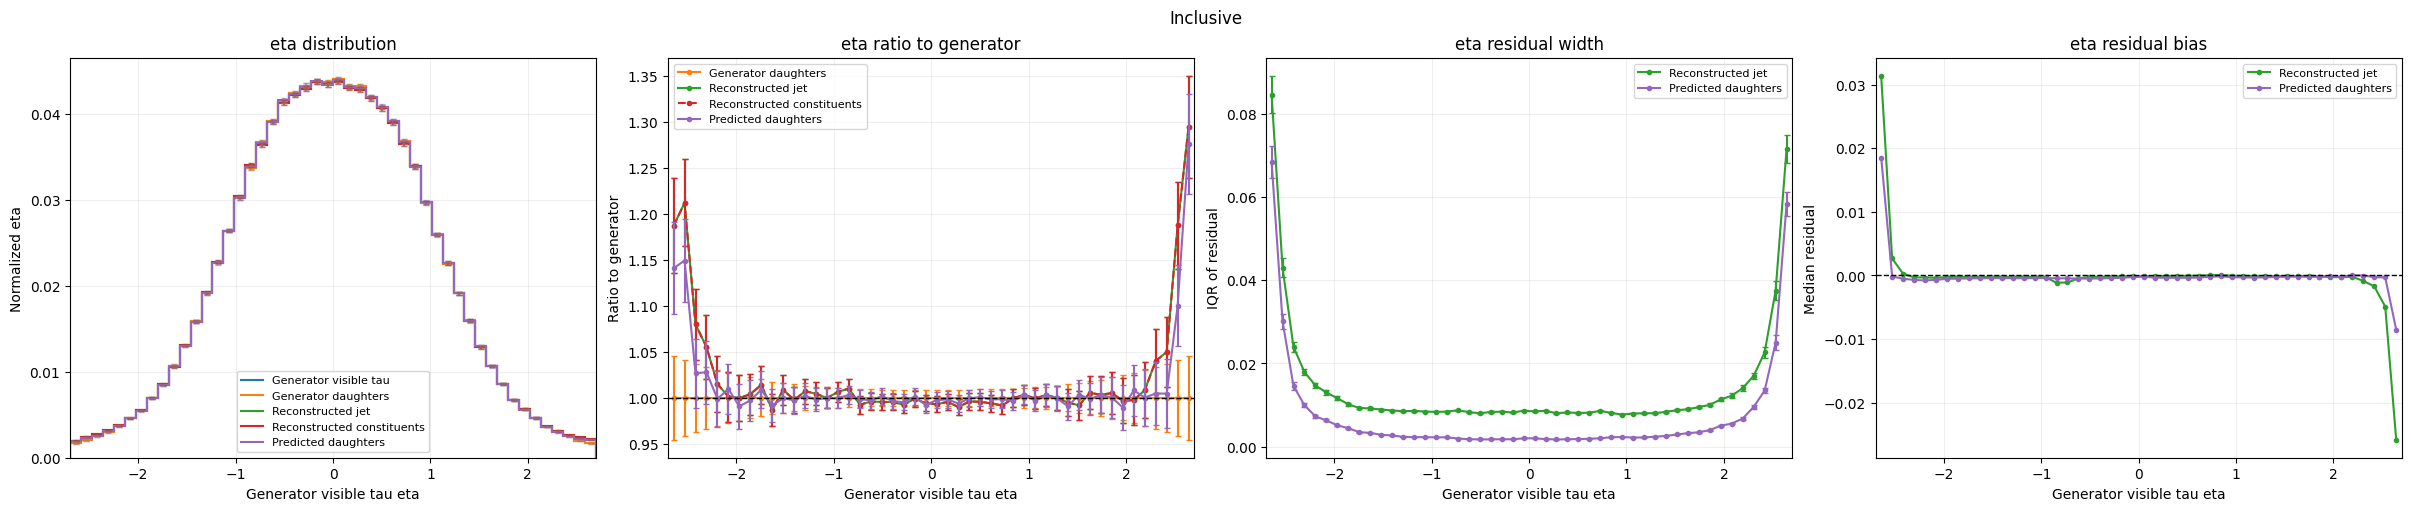

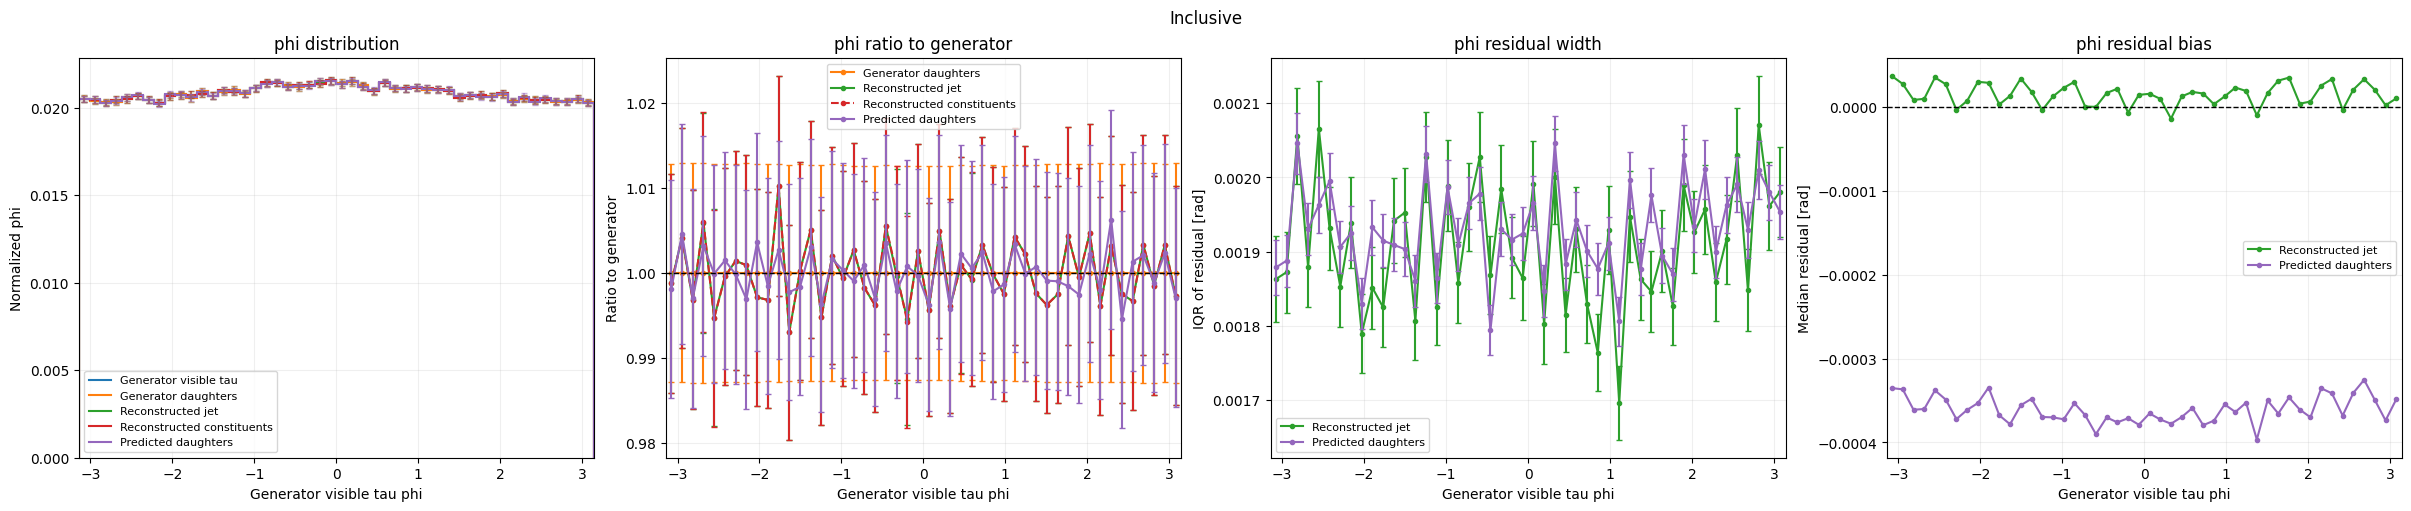

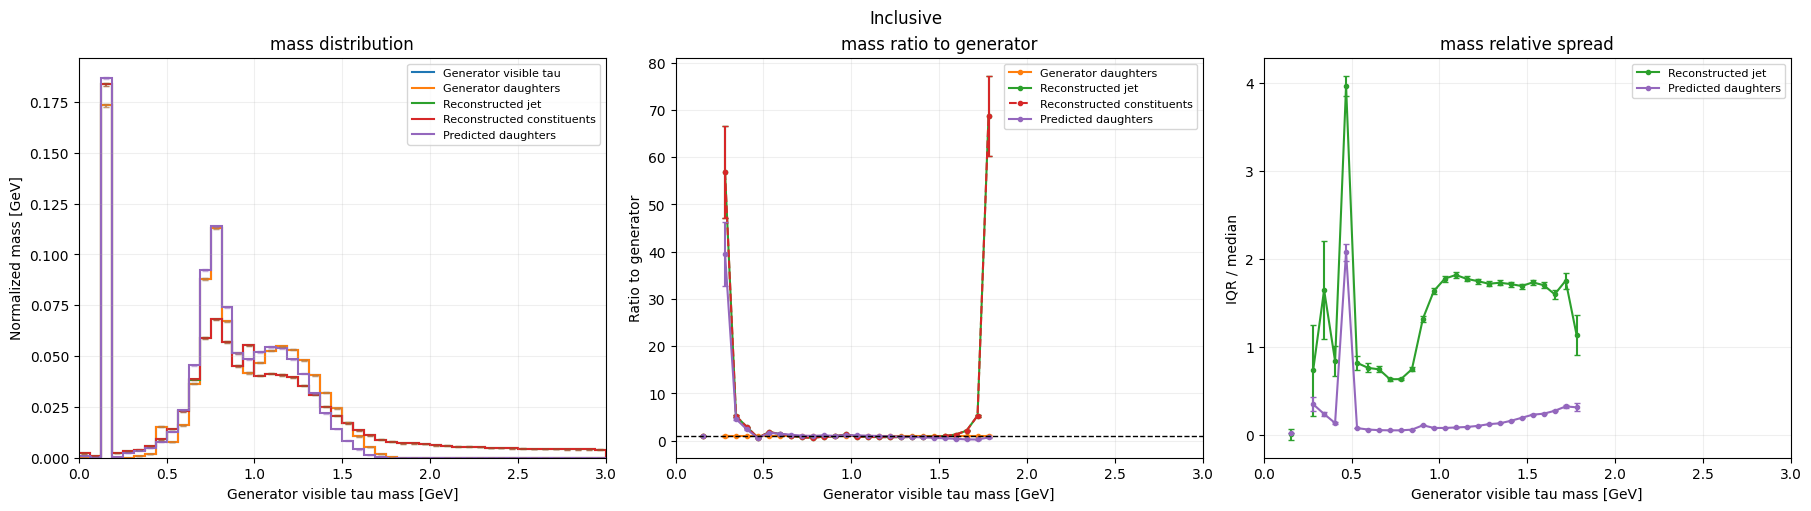

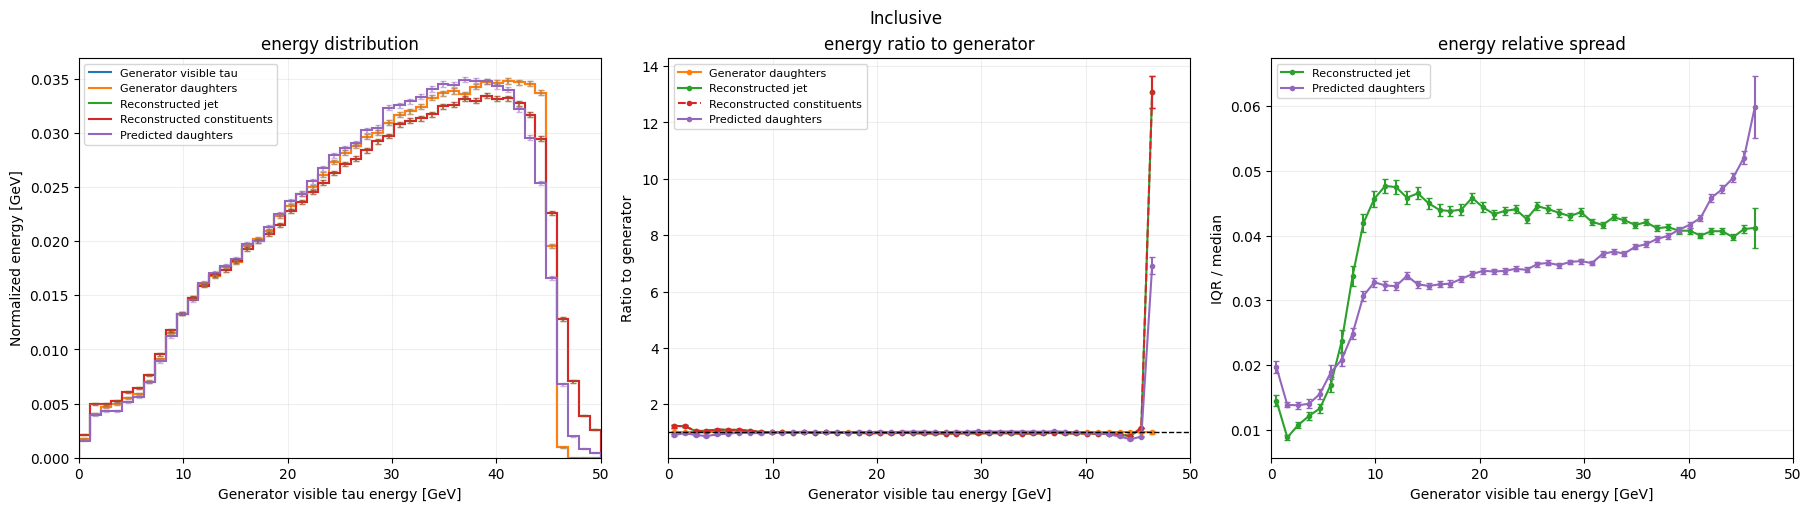

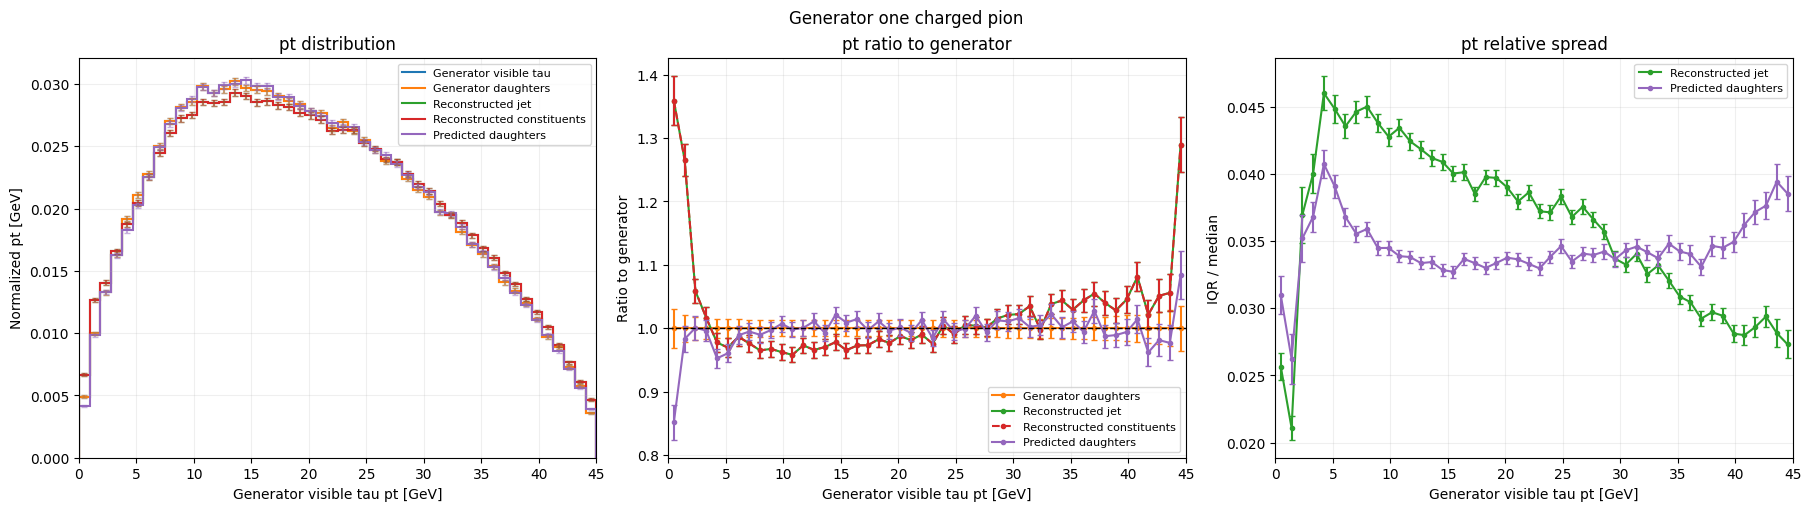

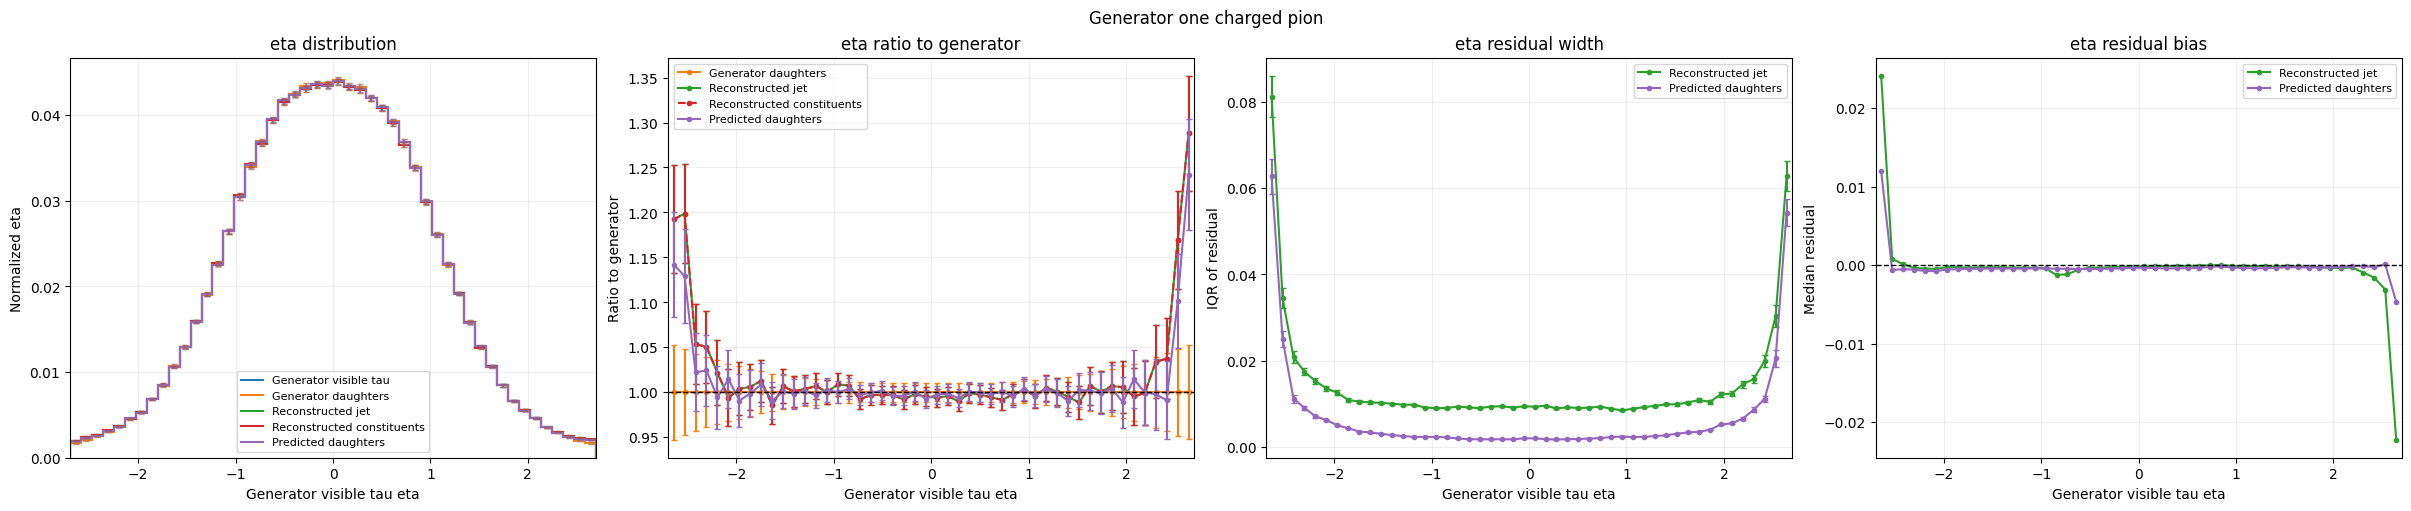

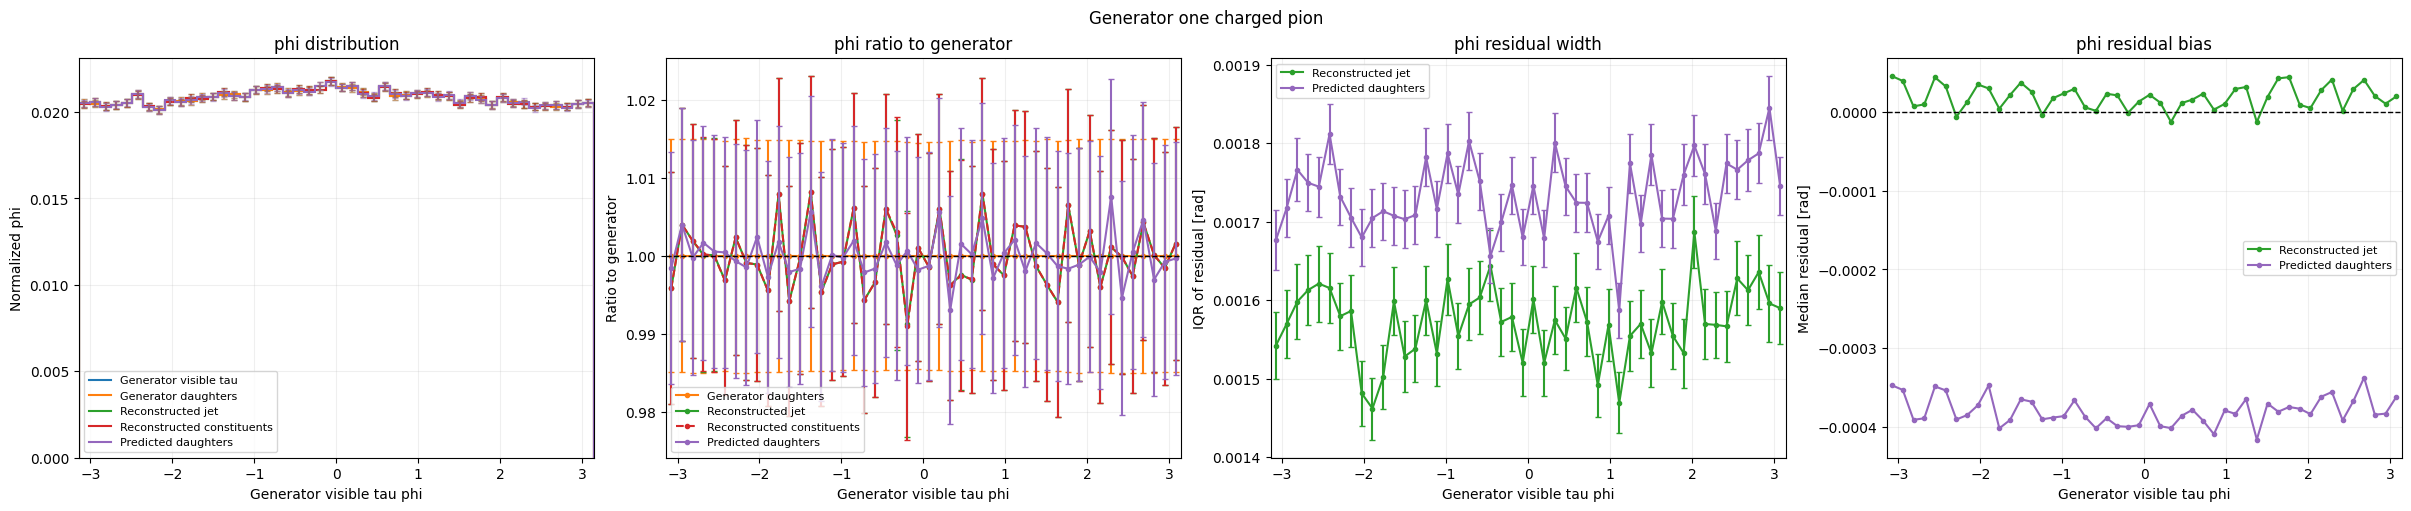

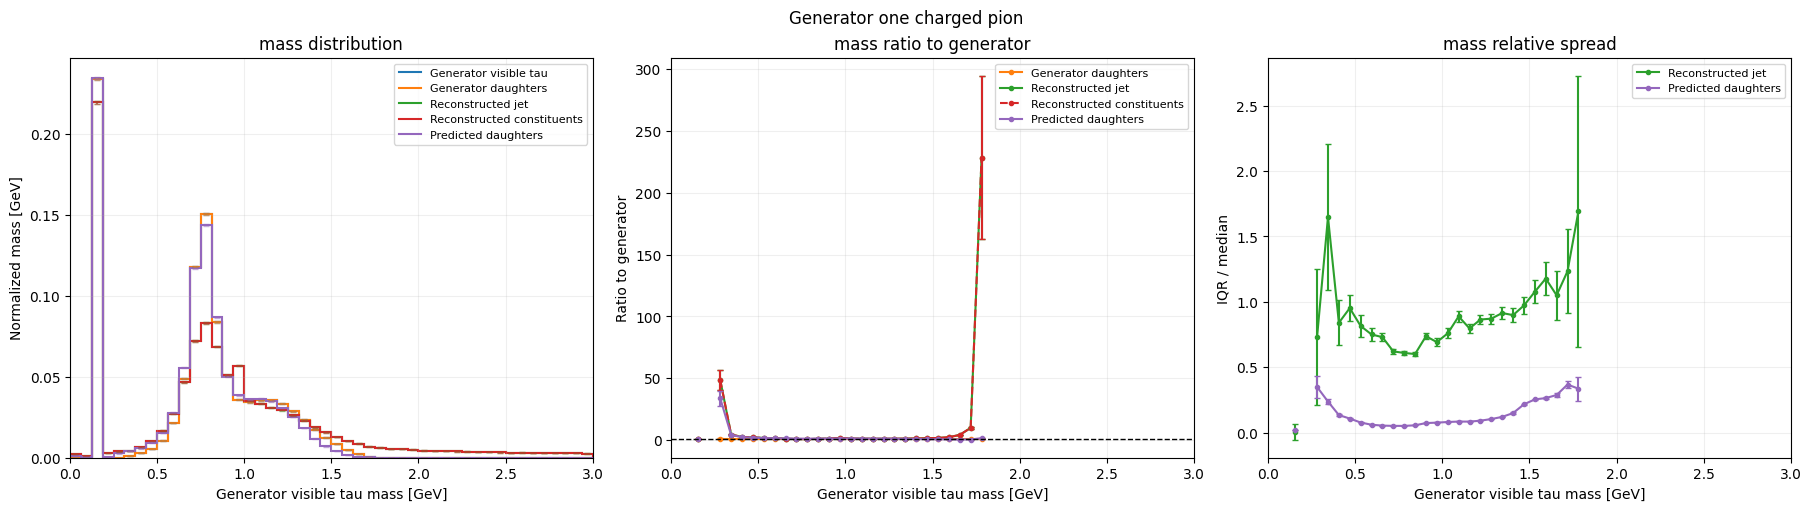

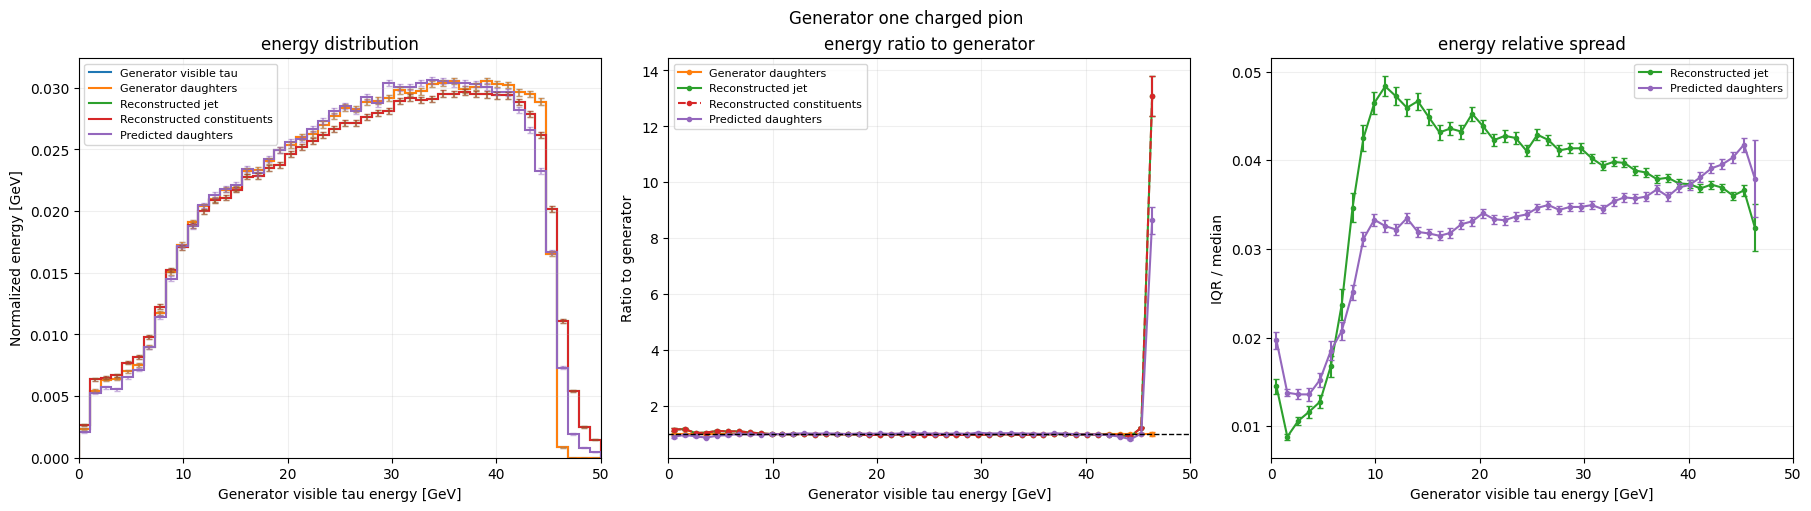

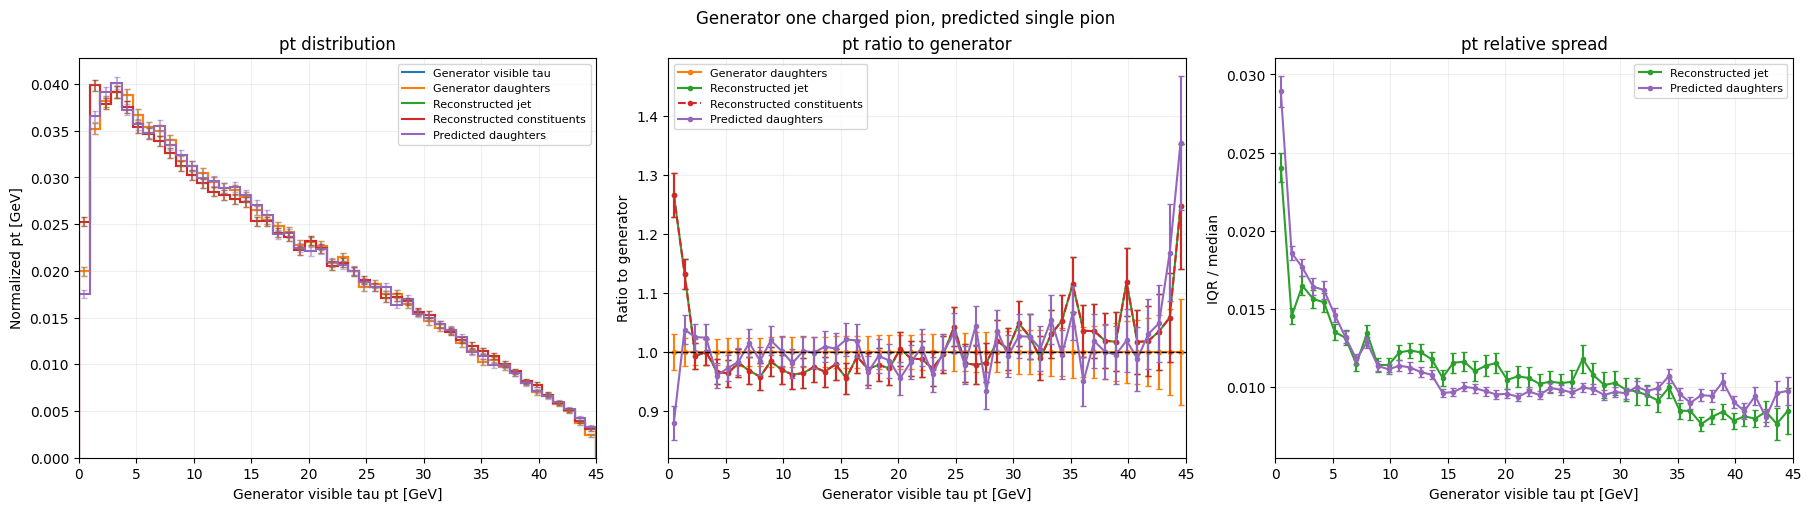

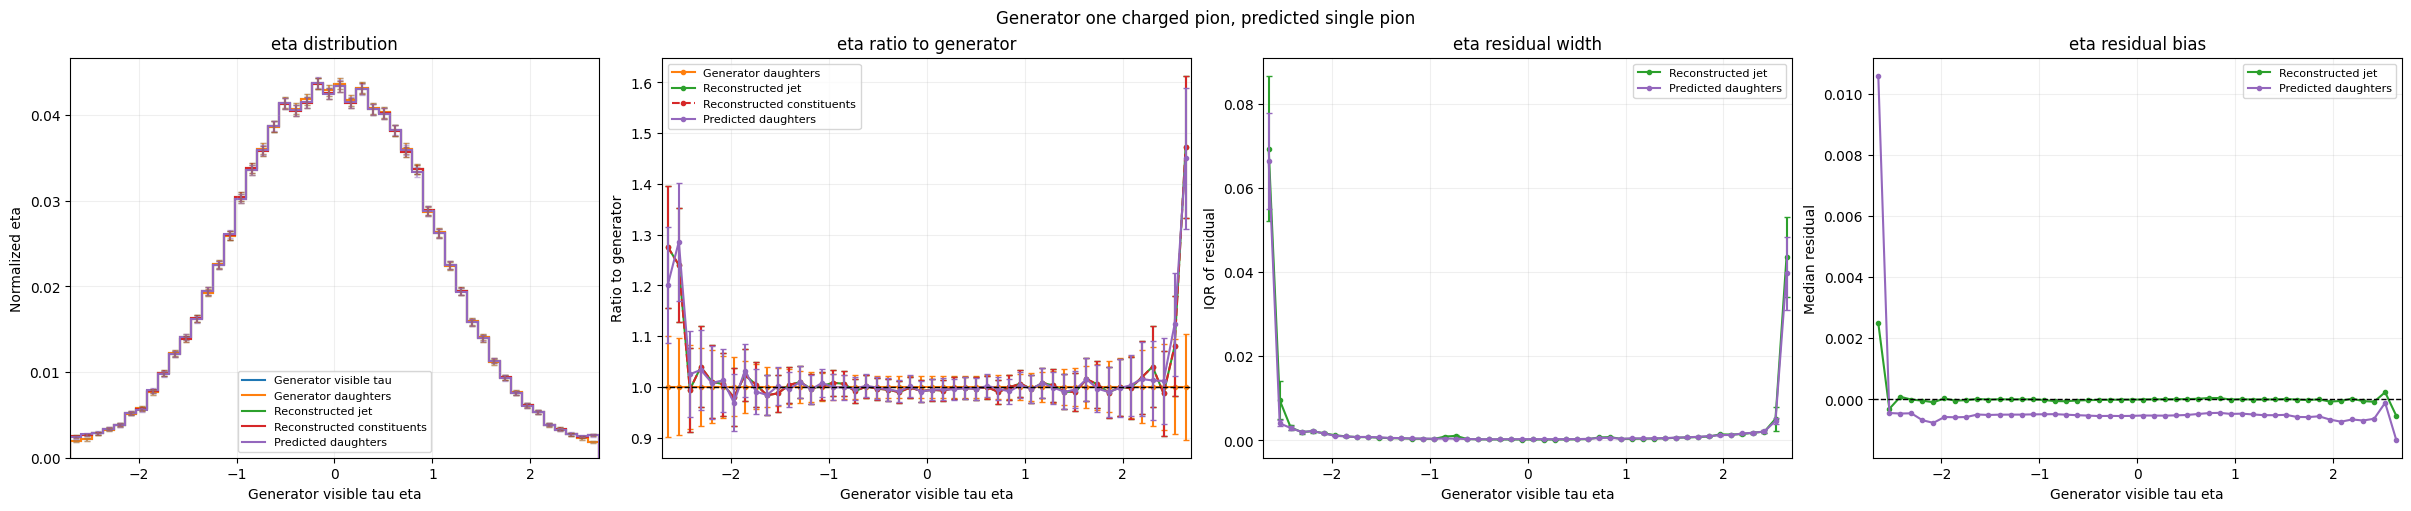

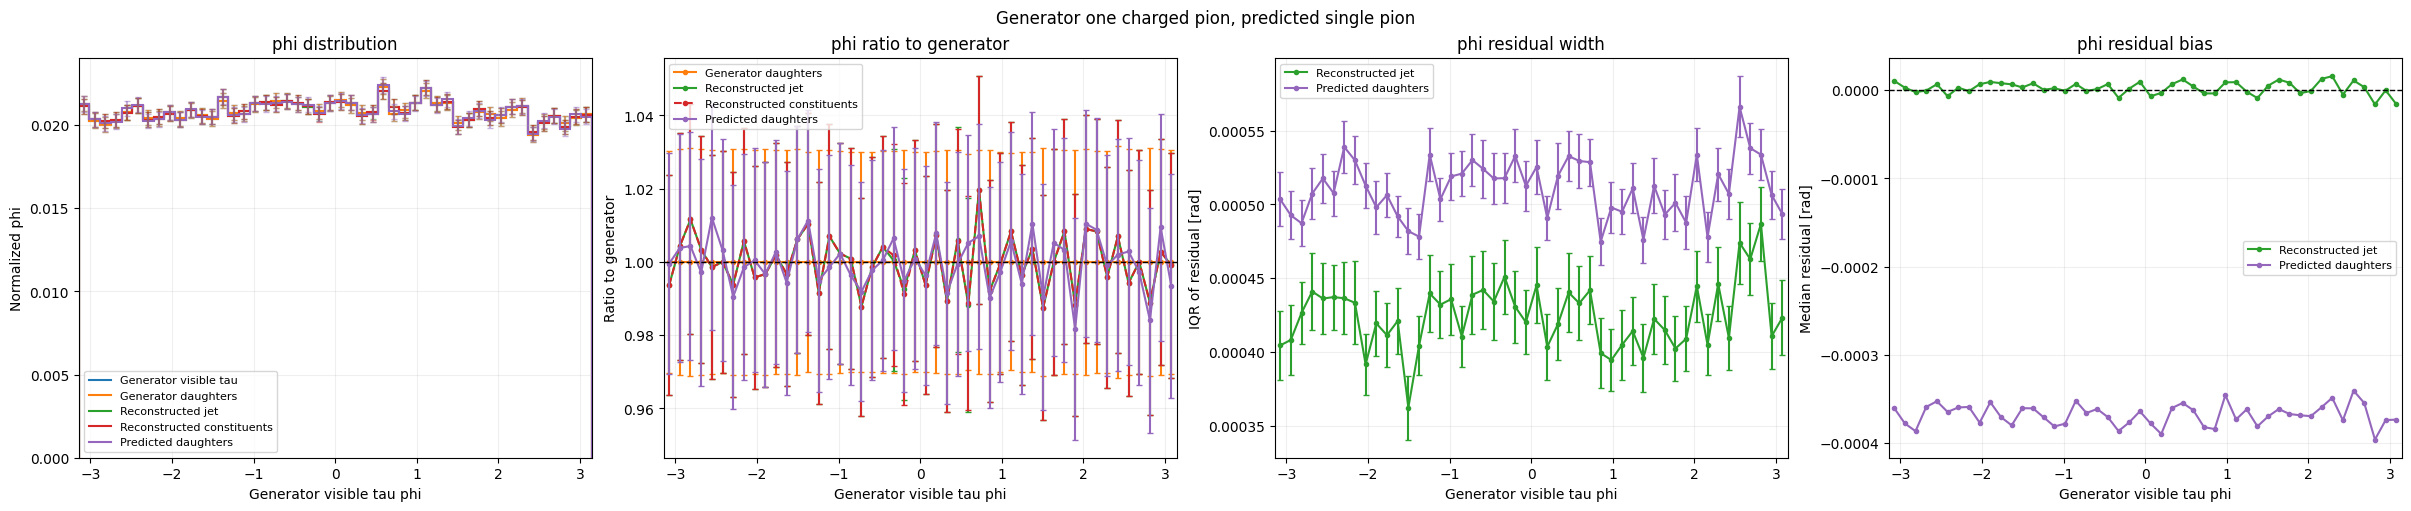

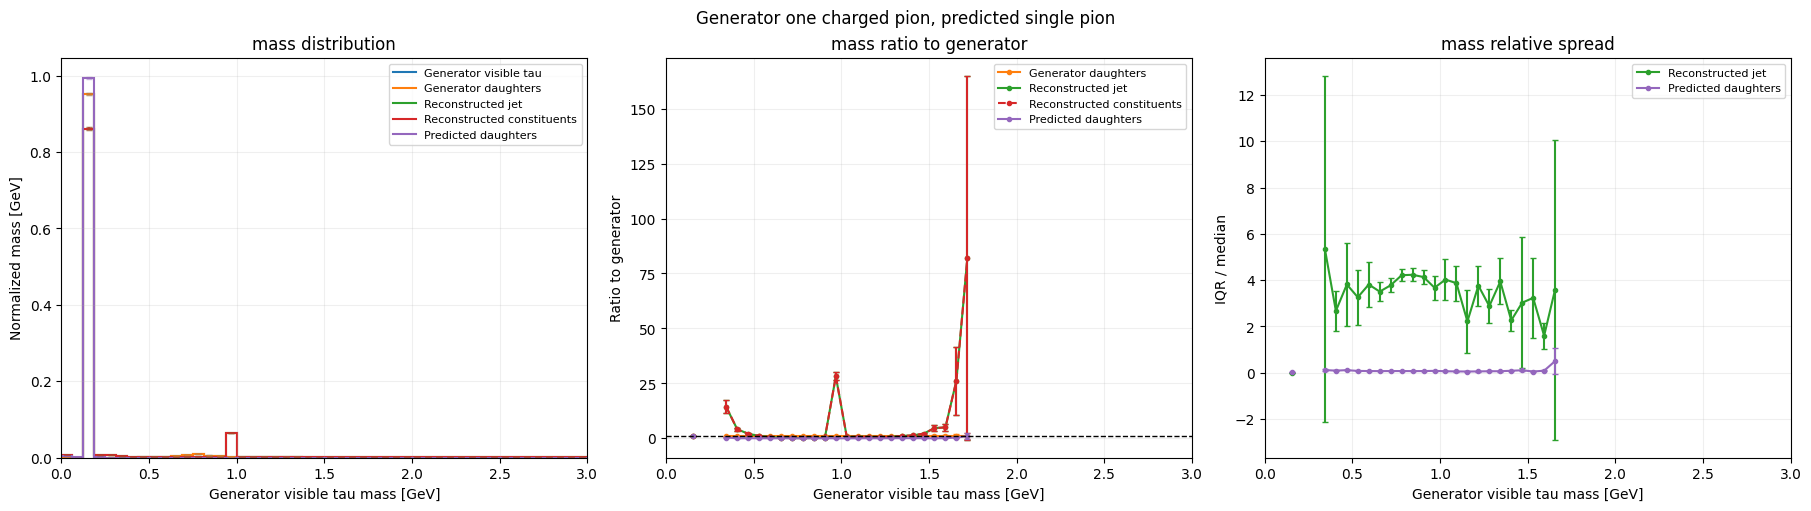

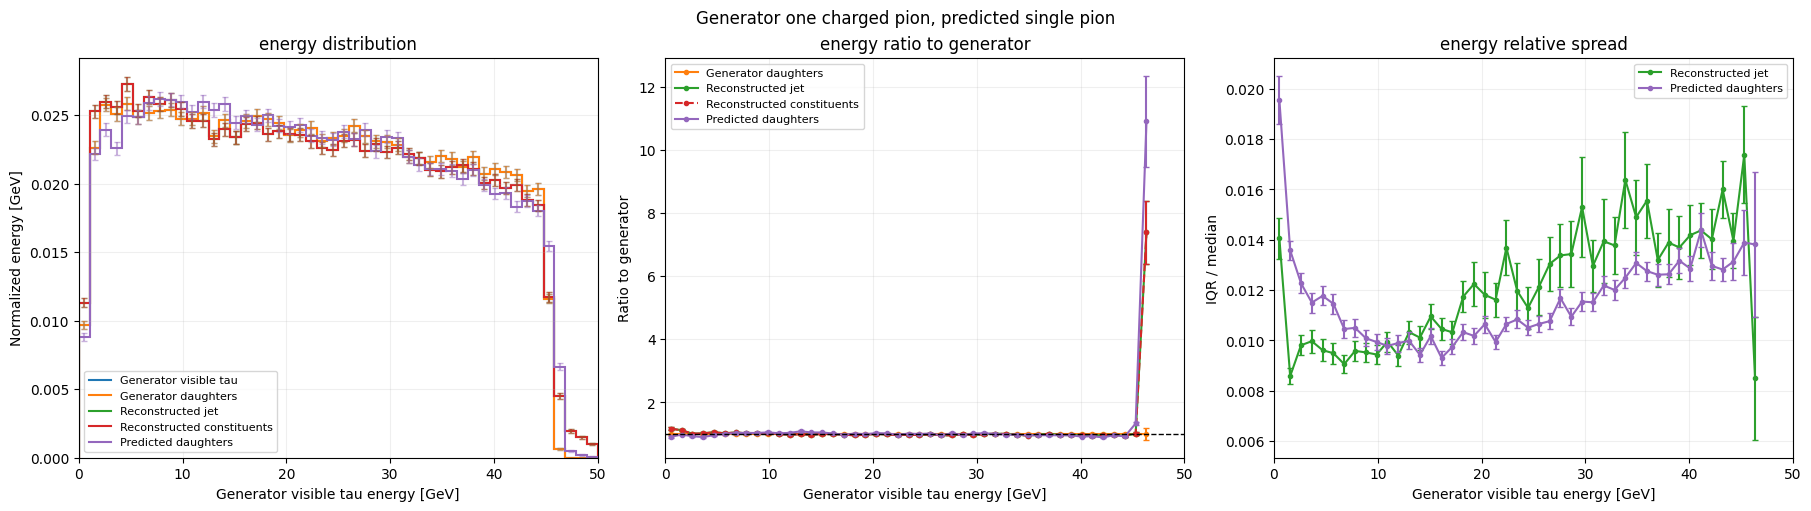

In [12]:
for selection_label, event_mask in event_selections.items():
    for quantity in quantity_ranges:
        plot_quantity(quantity, event_mask=event_mask, selection_label=selection_label, use_quantile_bins=False)

In [ ]:
def plot_correlations(quantity, event_mask=None, selection_label="Inclusive"):
    generator_values = source_quantity(
        "gen_jet_tau_p4", quantity, is_array=False, event_mask=event_mask
    )
    comparison_values = {
        "Reconstructed jet": source_quantity(
            "reco_jet_p4", quantity, is_array=False, event_mask=event_mask
        ),
        "Summed predicted daughters": source_quantity(
            "pred_tau_daughter_p4s", quantity, is_array=True, event_mask=event_mask
        ),
    }
    value_range = quantity_ranges[quantity]
    unit = f" [{quantity_units[quantity]}]" if quantity_units[quantity] else ""
    bins = np.linspace(*value_range)
    cmap = mpl.colormaps["magma_r"].copy()
    cmap.set_bad("white")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, (comparison_name, values) in zip(axes, comparison_values.items()):
        mask = np.isfinite(generator_values) & np.isfinite(values)
        counts, _, _ = np.histogram2d(generator_values[mask], values[mask], bins=(bins, bins))
        normalized_counts = np.divide(
            counts,
            counts.sum(axis=1, keepdims=True),
            out=np.zeros_like(counts),
            where=counts.sum(axis=1, keepdims=True) > 0,
        )
        normalized_counts = np.ma.masked_where(counts.T == 0, normalized_counts.T)
        image = ax.pcolormesh(bins, bins, normalized_counts, cmap=cmap, vmin=0, vmax=1)
        ax.set(
            title=f"Generator vs {comparison_name.lower()}",
            xlabel=f"Generator visible tau {quantity}{unit}",
            ylabel=f"{comparison_name} {quantity}{unit}",
            xlim=value_range[:2],
            ylim=value_range[:2],
        )
        fig.colorbar(image, ax=ax, label="Fraction per generator bin")
    fig.suptitle(f"{selection_label}: {quantity} migration matrices")
    plt.show()
    plt.close()

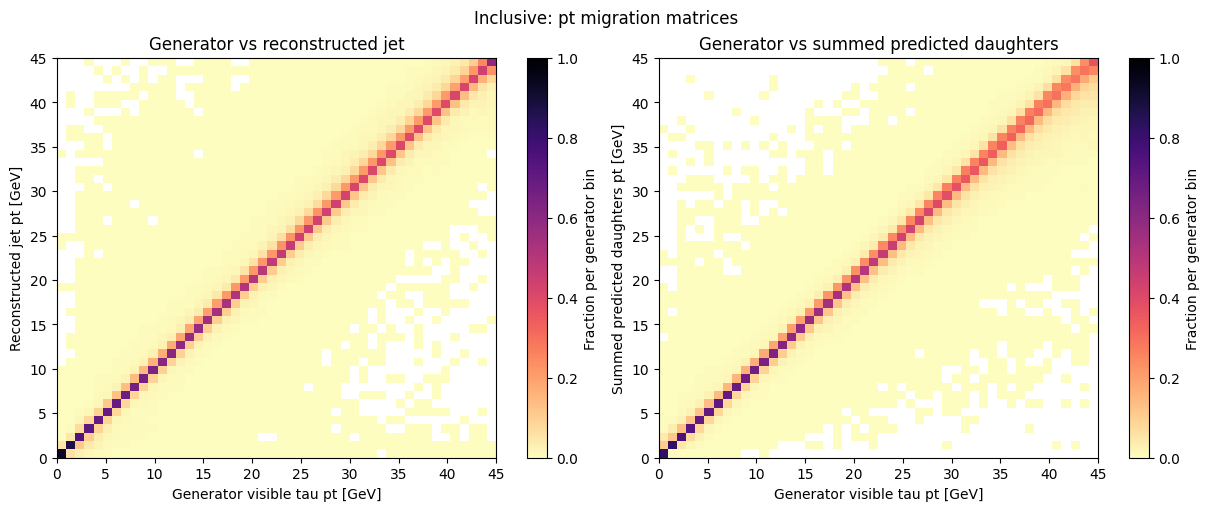

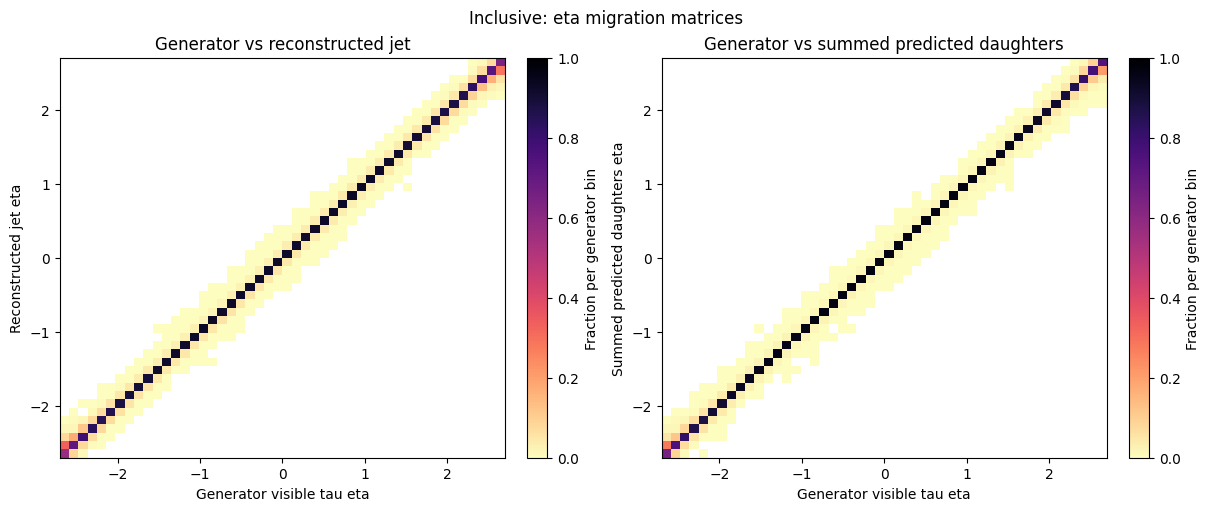

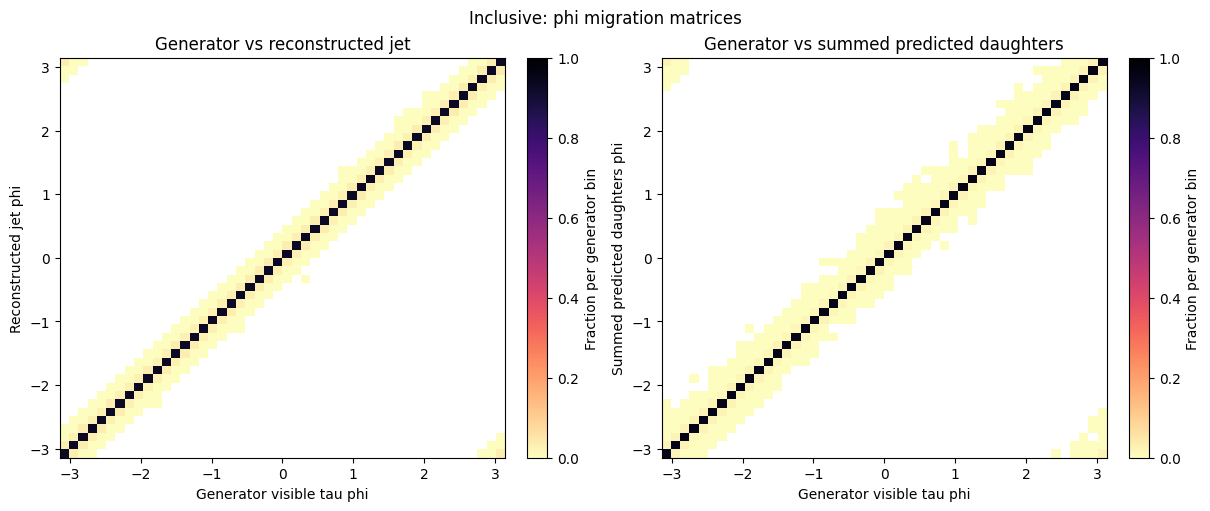

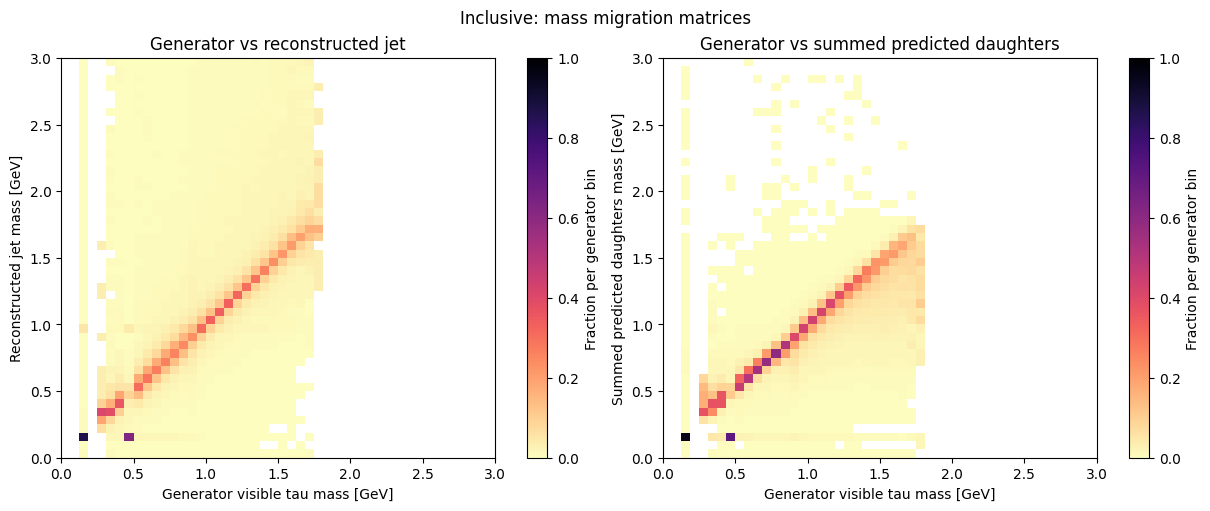

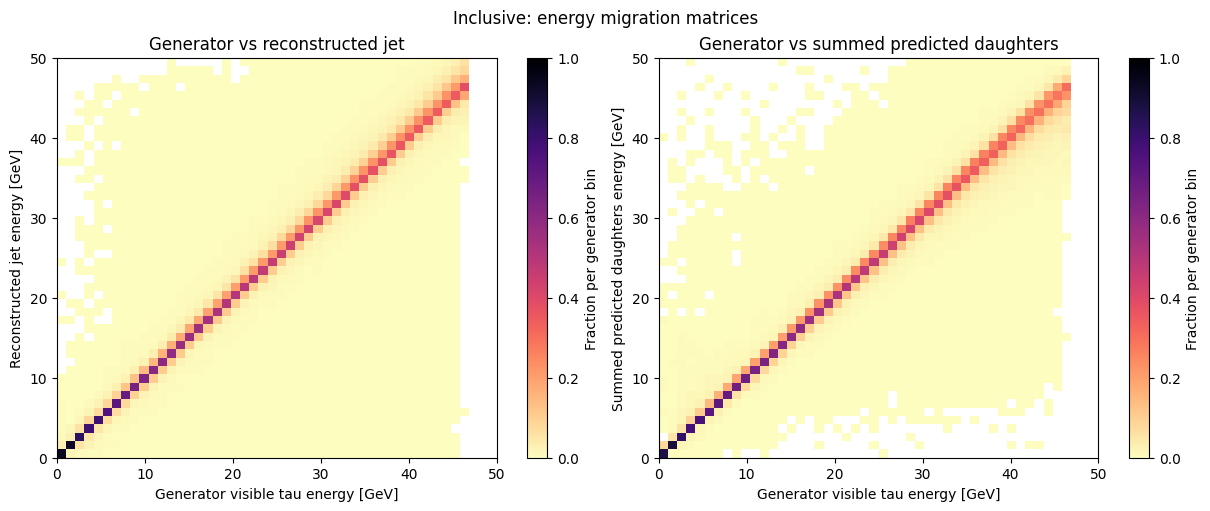

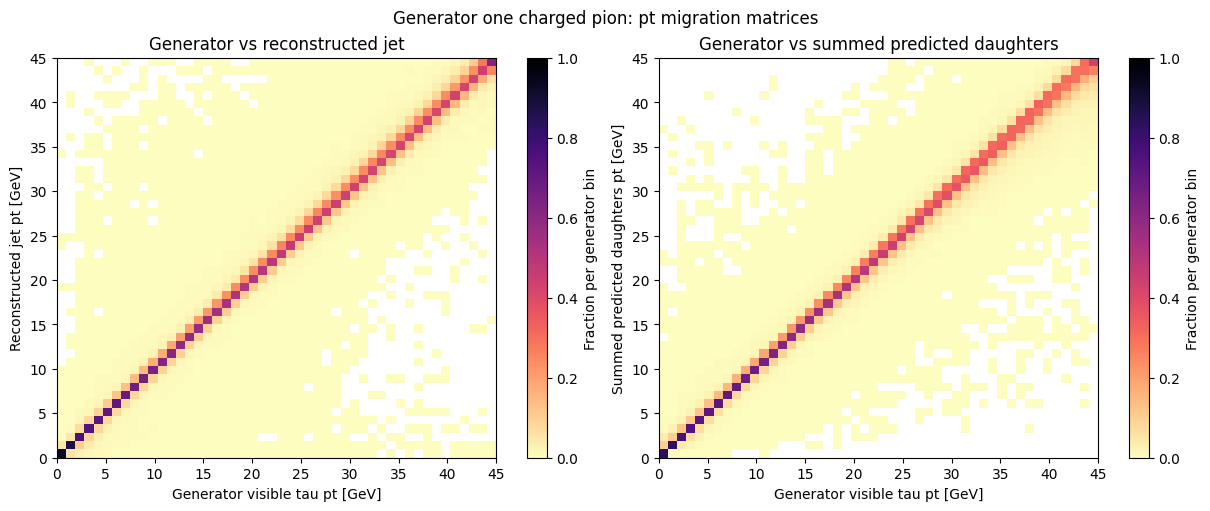

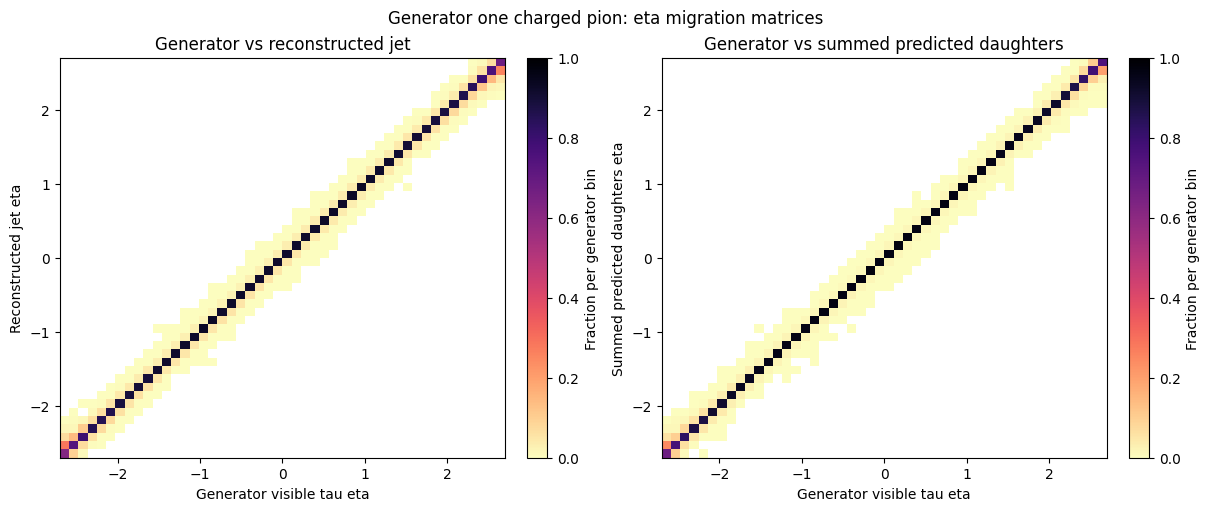

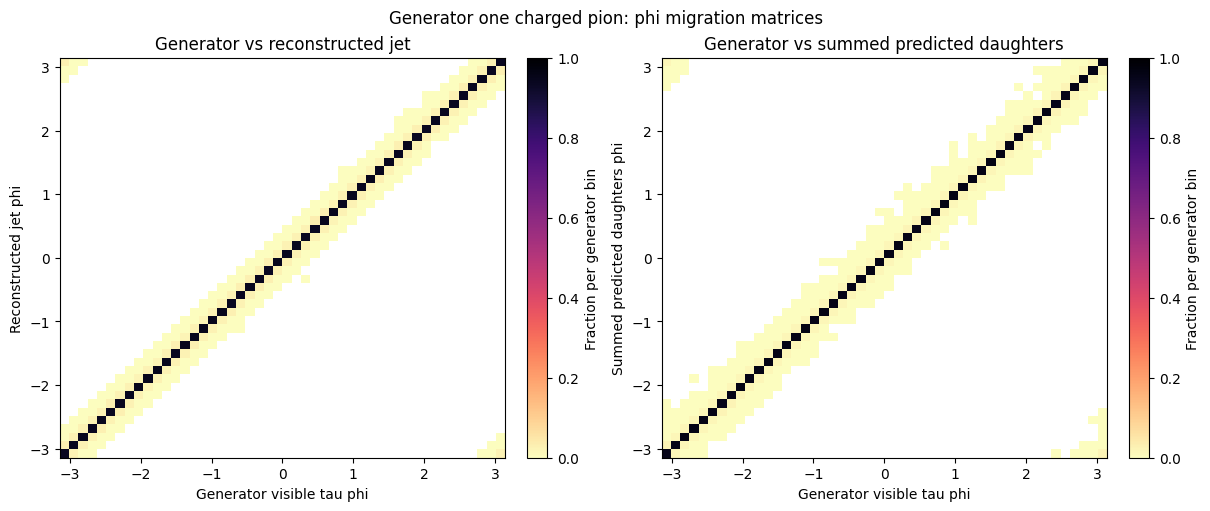

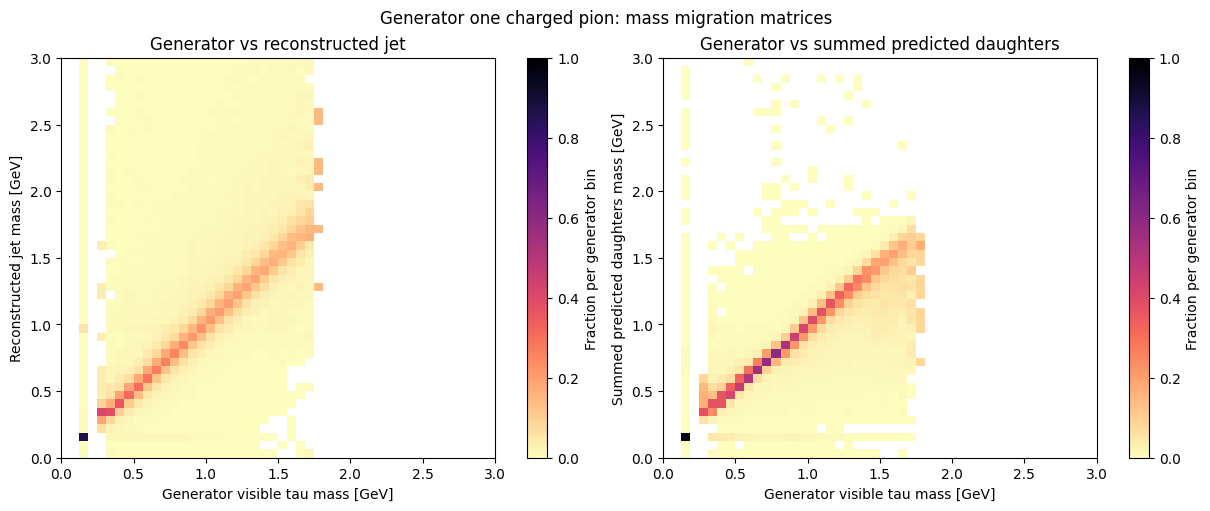

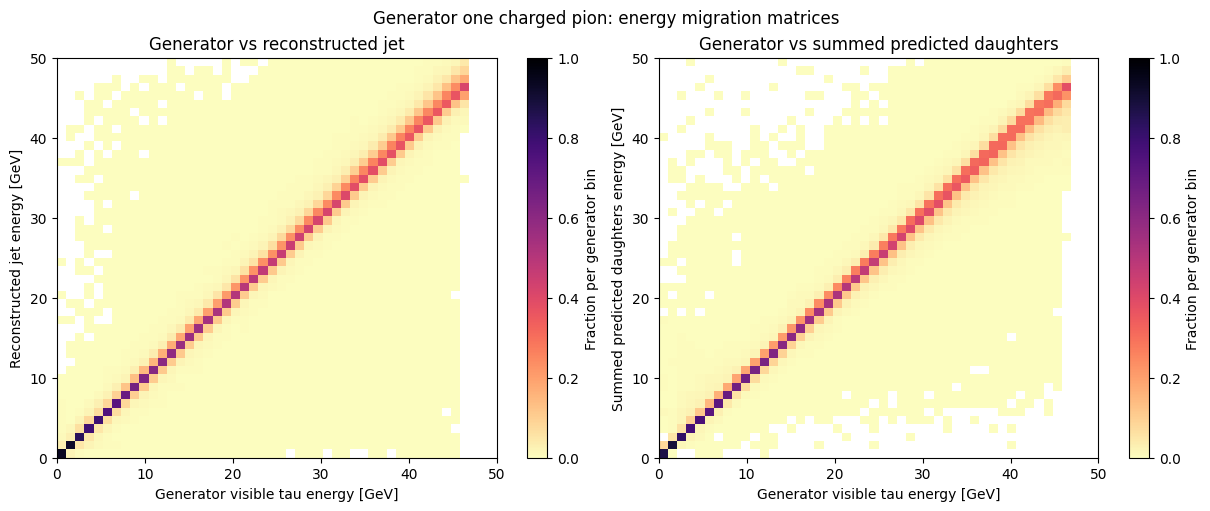

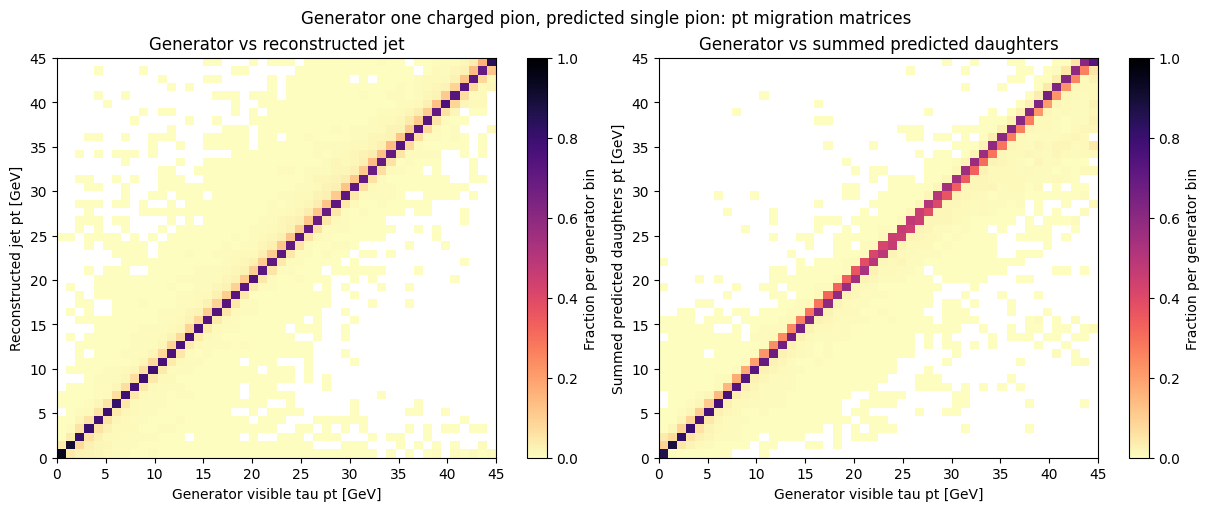

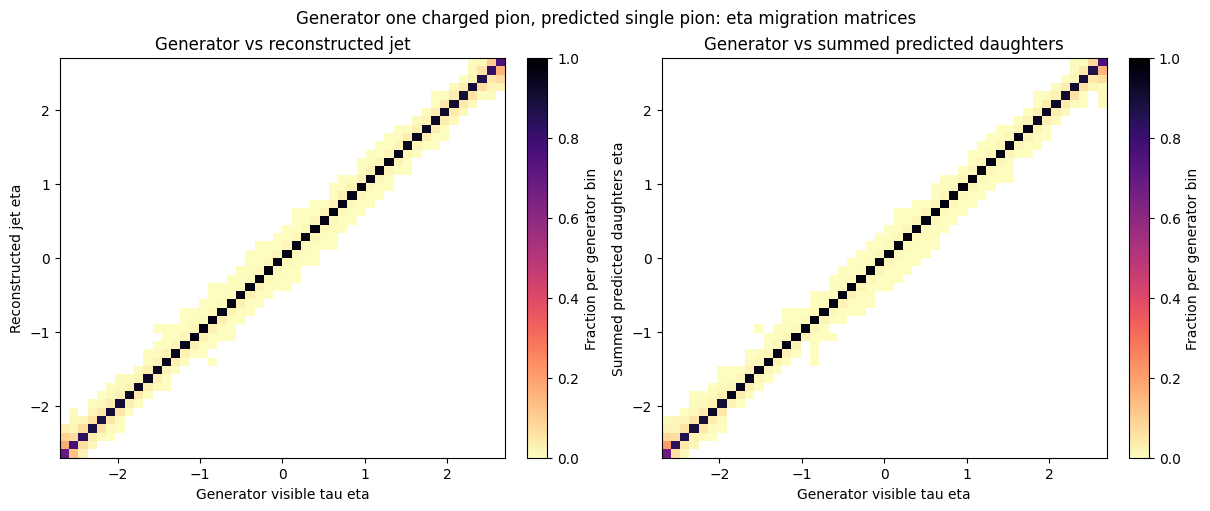

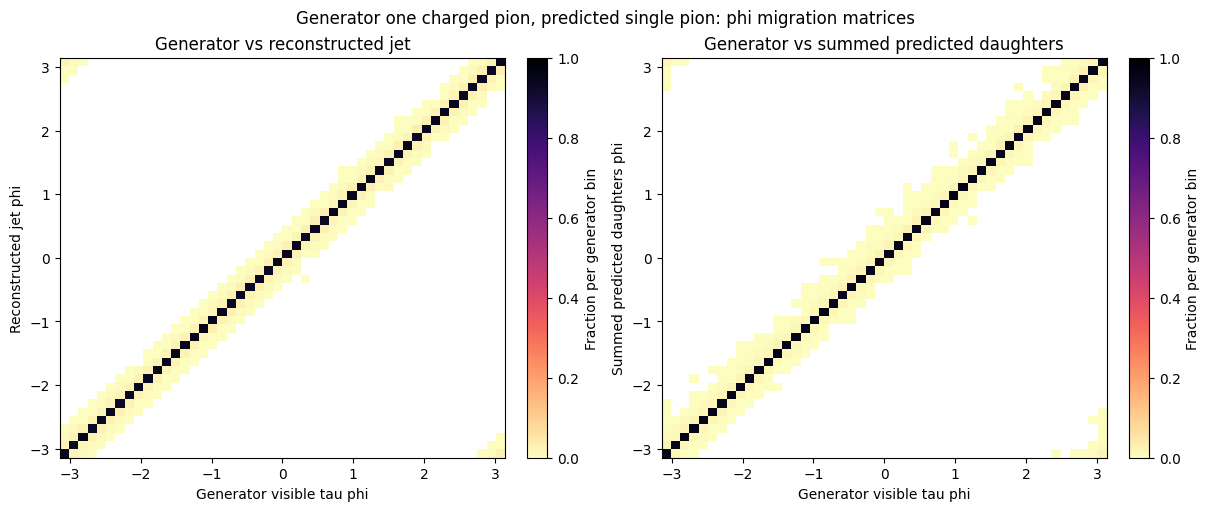

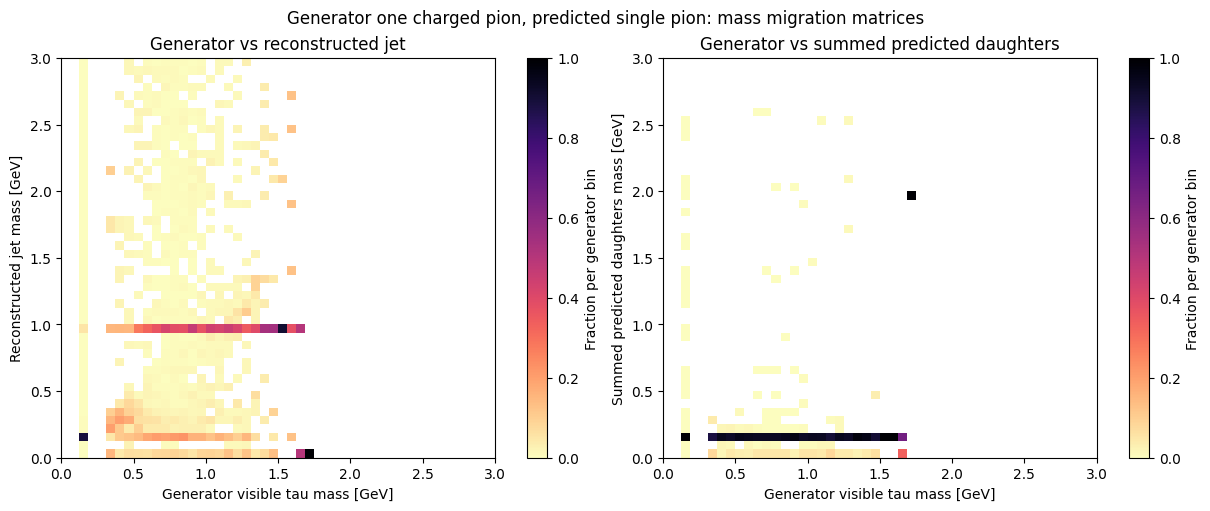

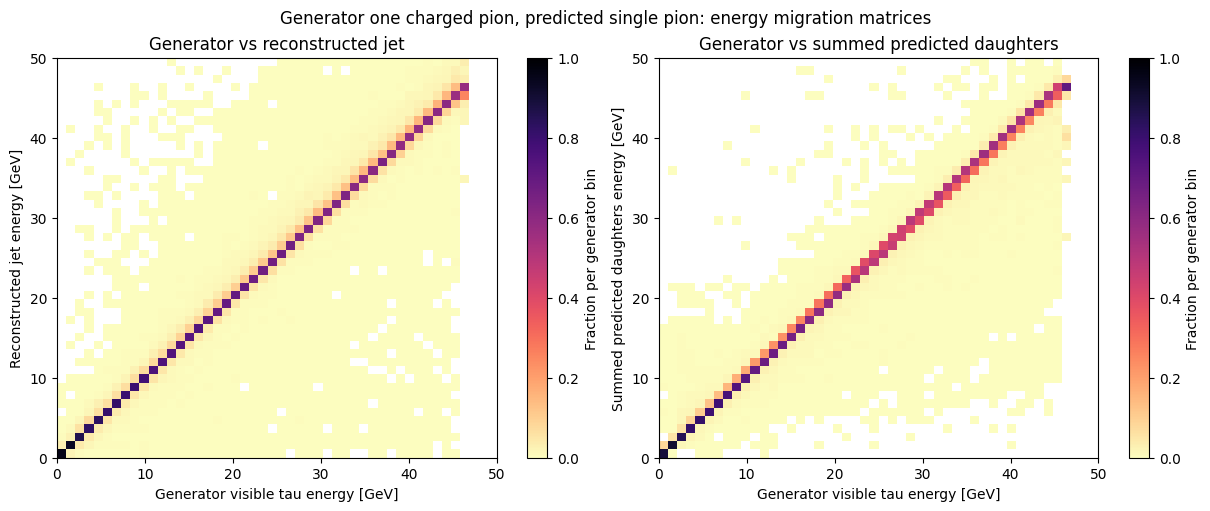

In [14]:
for selection_label, event_mask in event_selections.items():
    for quantity in quantity_ranges:
        plot_correlations(quantity, event_mask=event_mask, selection_label=selection_label)